### Sentiment analysis Model

**Problem Statement**

 vechile receive thousands of reviews daily. Manually understanding customer sentiment is impossible.

Goal :
Build a Sentiment Analysis Model that automatically classifies car review into:

* Negative

* Neutral

* Positive

🧠 ML Task Type

Supervised Learning

Multi-class Text Classification (NLP)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install gensim
import gensim
import re # Regular Expression Library
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
from gensim.parsing.preprocessing import remove_stopwords
from nltk.tokenize import word_tokenize # Tokenizaion
from spacy.lang.en import English
from spacy.lang.en.stop_words import STOP_WORDS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.6 MB/s eta 0:00:00


In [3]:
# Plotting libraries
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# sklearn :
import sklearn
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc

In [6]:
# load the dataset
# print the dataset
df = pd.read_csv('Review.csv')
df.head(100)

,Company,Model,Year,Reviewer,Date,Title,Rating,Review
0,acura,ilx,2013,mahowald,08/12/2012,Getting 43 Mpg on daily commute,5,"I love this car.\nGas mileage, suspension, and..."
1,acura,ilx,2013,VIP,07/26/2016,New to me ILX,5,I purchased my 2013 ILX from the dealer used w...
2,acura,ilx,2013,bybchucky,09/14/2013,Excellet Commuter Car,4,I recently purchased a 2013 ILX with the Tech ...
3,acura,ilx,2013,bayareamom,01/26/2015,Peppy Hybrid that Turns Heads,4,We bought our ILX used and have been incredibl...
4,acura,ilx,2013,Kerry Olson,03/26/2016,2013 Acura ILX Hybrid w/ Tech Package,5,In April of 2015 we were in need of another ca...
...,...,...,...,...,...,...,...,...
95,acura,ilx,2018,Fred,09/20/2018,Very good car for the money,4,I always admired this car when I saw it drivin...
96,acura,ilx,2018,Graham,05/03/2019,Love/Hate,5,Last June 2019 I sold my ILX lease to Carvana ...
97,acura,ilx,2018,john,08/31/2018,smaller is better,4,I had been driving an Acura TL and then TLX's ...
98,acura,ilx,2018,Nicole,12/04/2018,Acura ILX 2018 MAJOR ISSUES,5,"This is my third ILX because I LOVE this car, ..."


In [7]:
# diaplay the column name of our dataset
df.columns

Index(['Company', 'Model', 'Year', 'Reviewer', 'Date', 'Title', 'Rating',
       'Review'],
      dtype='object')

In [8]:
# information about the data set
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299045 entries, 0 to 299044
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Company   299045 non-null  object
 1   Model     299045 non-null  object
 2   Year      299045 non-null  int64 
 3   Reviewer  298938 non-null  object
 4   Date      299028 non-null  object
 5   Title     299010 non-null  object
 6   Rating    299045 non-null  int64 
 7   Review    299040 non-null  object
dtypes: int64(2), object(6)
memory usage: 18.3+ MB


,Year,Rating
count,299045.000000,299045.000000
mean,2007.492247,3.980886
std,5.330847,0.993001
min,2000.000000,0.000000
25%,2003.000000,4.000000
50%,2006.000000,4.000000
75%,2011.000000,5.000000
max,2020.000000,5.000000


In [9]:
df.isnull().sum()

,0
Company,0
Model,0
Year,0
Reviewer,107
Date,17
Title,35
Rating,0
Review,5


In [10]:
# Row an column in the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 299045
Number of columns: 8


In [11]:
df = df.drop([ 'Reviewer', 'Date', 'Title'], axis=1)

In [12]:
df.head(100)

,Company,Model,Year,Rating,Review
0,acura,ilx,2013,5,"I love this car.\nGas mileage, suspension, and..."
1,acura,ilx,2013,5,I purchased my 2013 ILX from the dealer used w...
2,acura,ilx,2013,4,I recently purchased a 2013 ILX with the Tech ...
3,acura,ilx,2013,4,We bought our ILX used and have been incredibl...
4,acura,ilx,2013,5,In April of 2015 we were in need of another ca...
...,...,...,...,...,...
95,acura,ilx,2018,4,I always admired this car when I saw it drivin...
96,acura,ilx,2018,5,Last June 2019 I sold my ILX lease to Carvana ...
97,acura,ilx,2018,4,I had been driving an Acura TL and then TLX's ...
98,acura,ilx,2018,5,"This is my third ILX because I LOVE this car, ..."


In [13]:
# Check for duplicate rows in the entire dataset
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Display a few duplicates if they exist
if duplicate_count > 0:
    display(df[df.duplicated()].head())

Number of duplicate rows: 807


,Company,Model,Year,Rating,Review
383,acura,mdx,2002,4,I have fallen in love with a car/ suv. \nSo fa...
1403,acura,mdx,2008,5,This is our 2nd MDX. Poor mileage is because ...
1550,acura,mdx,2010,5,This was my first Acura. I switch from a Volvo...
1742,acura,mdx,2014,5,I totaled my 2009 Acura MDX but the safety fea...
1903,acura,mdx,2016,5,


In [14]:
# Remove duplicate rows
df = df.drop_duplicates()
print(f"Duplicates removed. New dataset shape: {df.shape}")

Duplicates removed. New dataset shape: (298238, 5)


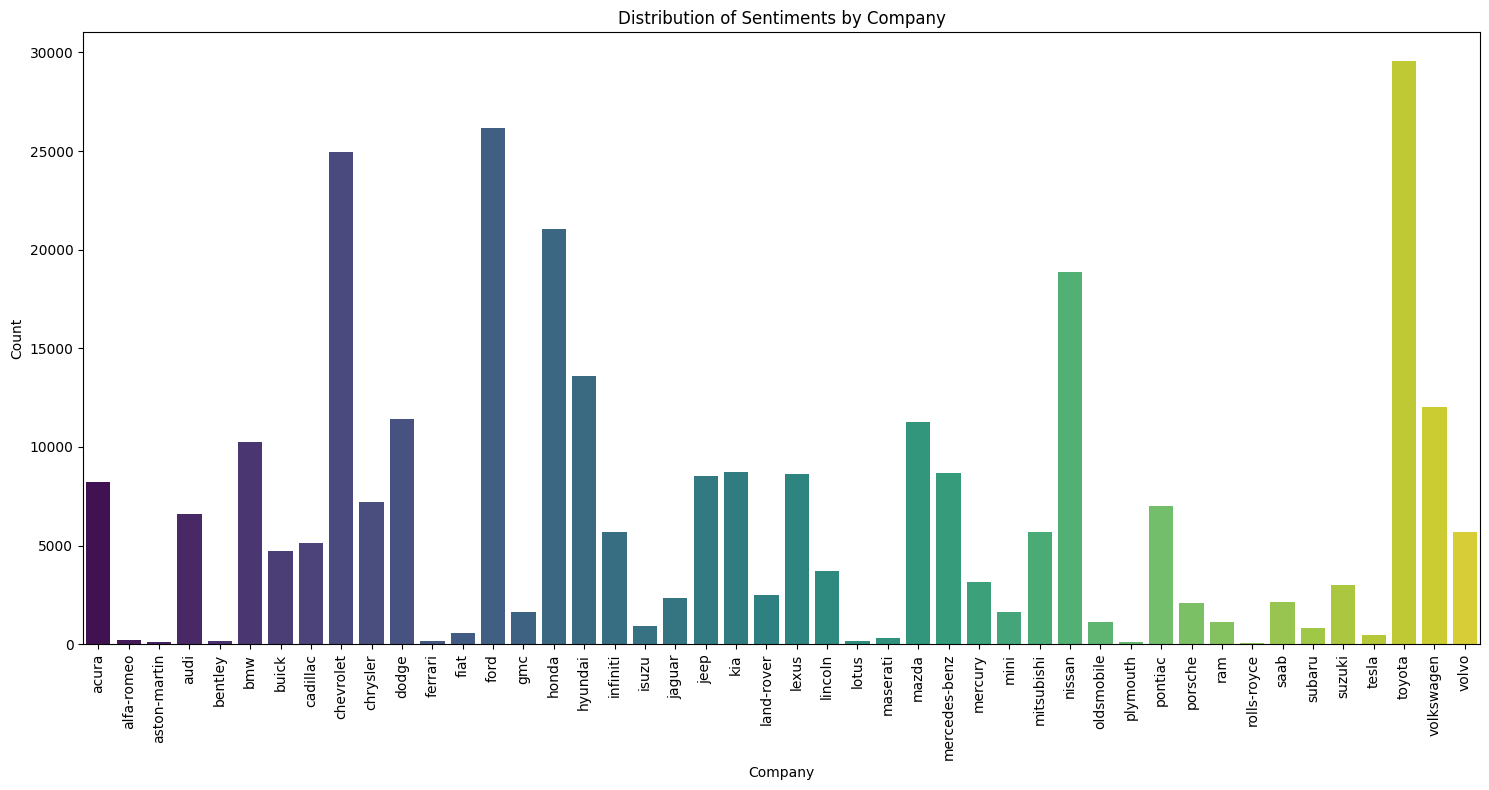

In [15]:
plt.figure(figsize=(15, 8))
sns.countplot(x='Company', data=df, palette='viridis')
plt.title('Distribution of Sentiments by Company')
plt.xlabel('Company')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [16]:
num_companies = df['Company'].nunique()
print(f"There are {num_companies} unique companies in the dataset.")

There are 46 unique companies in the dataset.


Step 2 - Text preprocessing





**Text processing**

Our data generally comes from a variety of different sources and is often in a variety of different formats. For this reason, cleaning our raw data is an essential part of preparing our dataset. However, cleaning is not a simple process, as textual data often contains redundant and/or repetitive words.

Before training the model, we will perform various pre-processing steps on the dataset such as:

* Removing stop words.
* Removing emojis.
* Removing of mentions.
* Removal of numbers.
* Removal of whitespaces.
* Removal of duplicated rows.
* Removal of unuseful columns.
* Converting the text document to lowercase for better generalization.
* Cleaning the ponctuation (to reduce unnecessary noise from the dataset).
* Removing the repeating characters from the words along with removing the URLs/hyperlinks as they do not have any significant importance.

`Stemming` : reducing the words to their derived stems.
`Lemmatization` : reducing the derived words to their root form known as lemma for better result



In [20]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

ps = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


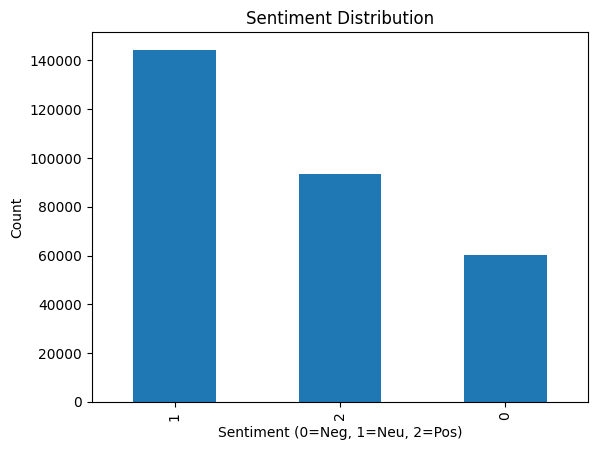

In [21]:
import matplotlib.pyplot as plt

# Count values
sentiment_counts = df['Sentiment'].value_counts()

# Plot
plt.figure()
sentiment_counts.plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0=Neg, 1=Neu, 2=Pos)")
plt.ylabel("Count")

plt.show()

In [22]:
# 3. Data Cleaning
df = df[['Review', 'Rating']].dropna()

* Removal of Mentions:

In social media, Mentions are used to call/mention another user into our post. Generally, mentions don't have an added value to our model. So we will remove them.

A mention has a special pattern: **@UserName,** So we will remove all string which starts with @

In [23]:
# Removal of Mentions:

## Creating a fucntion that will be applied to our datset :
def RemoveMentions(Review):
    text_ = re.sub(r"@\S+", "", Review)
    return text_


## Applying the function to each row of the data
print("=========== Before Removing Mentions ============\n")
print("\t" + df.loc[5, "Review"])
print("\n=========== After Removing Mentions ===========\n")
df["Review"] = df["Review"].apply(RemoveMentions)
print("\t" + df.loc[5, "Review"])

=========== Before Removing Mentions ============

	Just upgraded from my 5-spd Saab 9-3 sedan to a brand new Acura ilx w/premium package and the 2.4L 6-spd engine.
The premium package comes with nearly everything that you could ask for minus navigation.

Very nice engine note that gives the car some personality without sounding like a cheap tuner.
The only knock I could say about the ilx is the interior space which is expected to be small due to the price point and market that Acura intends to target.

If you're in your 20s or early 30s and are looking for something fun to drive without sacrificing the luxury amenities, look no further than the ilx.

Oh and by the way, I'm getting 35-40 highway mpg.

=========== After Removing Mentions ===========

	Just upgraded from my 5-spd Saab 9-3 sedan to a brand new Acura ilx w/premium package and the 2.4L 6-spd engine.
The premium package comes with nearly everything that you could ask for minus navigation.

Very nice engine note that gives th

* Removal of Special Characters:

Special characters are every where, since we have punctuation marks in our tweets. In order to treat, for example, hello! and hello in the same way. we have to remove the punctuation mark.

In [24]:
# Defining a list containing punctuation signs of english :
punctuations_list = string.punctuation


## Defining that will be applied to our datset :
def RemovePunctuations(Review):
    transformator = str.maketrans('', '', punctuations_list)
    return Review.translate(transformator)


## Applying the fucntion to all rows :
print("=========== Before Removing Punctuations =============\n")
print("\t" + df.loc[10, "Review"])
print("\n=========== After Removing Punctuations \===========\n")
df["Review"] = df["Review"].apply(RemovePunctuations)
print("\t" + df.loc[10, "Review"])

=========== Before Removing Punctuations =============

	Grown up with a 6 speed. Smooth shifting tranny. Soft touches allover. Smart phone integration is incredible. 

=========== After Removing Punctuations \===========

	Grown up with a 6 speed Smooth shifting tranny Soft touches allover Smart phone integration is incredible 


* Removal of Stop words:

Stopwords are the most common words in any natural language. For the purpose of analyzing text data and building NLP models, these stopwords might not add much value to the meaning of the document.

Generally, the most common words used in a text are “the”, “is”, “in”, “for”, “where”, “when”, “to”, “at” etc.

Consider this text string – “There is a pen on the table”. Now, the words “is”, “a”, “on”, and “the” add no meaning to the statement while parsing it. Whereas words like “there”, “book”, and “table” are the keywords and tell us what the statement is all about.

* Stopword Removal using NLTK:

NLTK, or the Natural Language Toolkit, is a treasure trove of a library for text preprocessing. It’s one of my favorite Python libraries. NLTK has a list of stopwords stored in 16 different languages.

In [25]:
df.loc[10, "Review"]

'Grown up with a 6 speed Smooth shifting tranny Soft touches allover Smart phone integration is incredible '

In [26]:
df.loc[100, "Review"]

'I own this car and I really regret itthe features on a civil has way more technology and way  advanced then this ilx The seat are not even manual on the passenger It’s doesn’t have push start remote like civil or has navigation even the back up cam don’t have a beep sounds It’s very very low grade then a Honda civil Really not worth the price and quality \n'

In [27]:
df.loc[10000, "Review"]

'Well designed comfortable back seat in the older models not as space efficient as it should be for legroom\n'

In [32]:
import nltk.corpus
# Getting the pre defined stop words from nltk library :
# Using a new variable name to store the list of stopwords to avoid overwriting the module reference.
english_stopwords_list = nltk.corpus.stopwords.words('english')

## Copying the df to use other libraries (spacy and gensim)
df_copy1 = df.loc[:100].copy(deep=True)
df_copy2 = df.copy(deep=True)  # deep copy to create another df

## Applying the fucntion to all rows
print("=========== Before Removing Stop words ============\n")
print("\t" + df_copy2.loc[12, "Review"])
print("\n=========== After Removing Stop words ===========\n")

## Exclude stopwords with Python's list comprehension and pandas.DataFrame.apply.
df_copy2['Review'] = df_copy2['Review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (english_stopwords_list)]))
print("\t" + df_copy2.loc[12, "Review"])

=========== Before Removing Stop words ============

	The Ilx is a great car I am a HondaAcura fan which is a big part of why I purchased this car
You can get more car for the money with Toyota Honda or Nissan any day but if you want the Acura badge and build quality you pay the premium The car handles extremely well road noise is pretty low and the interior is one of the most comfortable and aesthetically appealing of any car I have owned The interior isnt large but its done very well I really enjoy driving this car and it gets its fair share of looks Dont judge this car by pictures I went to the dealer to buy a tsx and left with this because when I saw it the body styling really hooked me in It is definitely not a rebadged civic

=========== After Removing Stop words ===========

	The Ilx great car I HondaAcura fan big part I purchased car You get car money Toyota Honda Nissan day want Acura badge build quality pay premium The car handles extremely well road noise pretty low interior

`Removal of Stop words using NLTK was successfully applied to our data`

* Stopword Removal using spaCy:

spaCy is one of the most versatile and widely used libraries in NLP. We can quickly and efficiently remove stopwords from the given text using SpaCy. It has a list of its own stopwords that can be imported as STOP_WORDS from the spacy.lang.en.stop_words class.

In [34]:
## Creating a fucntion that will be applied to our datset :
def RemoveStopsSpacy(Review):
    # Load English tokenizer, tagger, parser, NER and word vectors
    nlp = English()

    #  "nlp" Object is used to create documents with linguistic annotations.
    my_doc = nlp(Review)

    # Create list of word tokens
    token_list = []
    for token in my_doc:
        token_list.append(token.text)
    # Create list of word tokens after removing stopwords
    filtered_sentence = []

    for word in token_list:
        lexeme = nlp.vocab[word]
        if lexeme.is_stop == False:
            filtered_sentence.append(word)
    return filtered_sentence


## Applying the fucntion to all rows
print("=========== Before Removing Stop words with spaCy ===========\n")
print("\t" + df_copy1.loc[12, "Review"])
print("\n=========== After Removing Stop words with spaCy ===========\n")

## Exclude stopwords with Python's list comprehension and pandas.DataFrame.apply.
df_copy1['Review'] = df_copy1['Review'].apply(lambda x: ' '.join(RemoveStopsSpacy(x)))
print("\t" + df_copy1.loc[12, "Review"])

=========== Before Removing Stop words with spaCy ===========

	The Ilx is a great car I am a HondaAcura fan which is a big part of why I purchased this car
You can get more car for the money with Toyota Honda or Nissan any day but if you want the Acura badge and build quality you pay the premium The car handles extremely well road noise is pretty low and the interior is one of the most comfortable and aesthetically appealing of any car I have owned The interior isnt large but its done very well I really enjoy driving this car and it gets its fair share of looks Dont judge this car by pictures I went to the dealer to buy a tsx and left with this because when I saw it the body styling really hooked me in It is definitely not a rebadged civic

=========== After Removing Stop words with spaCy ===========

	Ilx great car HondaAcura fan big purchased car 
 car money Toyota Honda Nissan day want Acura badge build quality pay premium car handles extremely road noise pretty low interior comfor

* Stopword Removal using Gensim:

Gensim is a pretty handy library to work with on NLP tasks. While pre-processing, gensim provides methods to remove stopwords as well. We can easily import the remove_stopwords method from the class gensim.parsing.preprocessing.

In [35]:
df.loc[8]

,8
Review,My previous car was a leased 2015 Civic EXL bu...
Rating,5


In [36]:
## Applying the fucntion to all rows
print("=========== Before Removing Stop words with Gensim =======\n")
print("\t" + df.loc[12, "Review"])
print("\n=========== After Removing Stop words with Gensim =======\n")
df['Review'] = df['Review'].apply(lambda x: gensim.parsing.preprocessing.remove_stopwords(x))
print("\t" + df.loc[12, "Review"])

=========== Before Removing Stop words with Gensim =======

	The Ilx is a great car I am a HondaAcura fan which is a big part of why I purchased this car
You can get more car for the money with Toyota Honda or Nissan any day but if you want the Acura badge and build quality you pay the premium The car handles extremely well road noise is pretty low and the interior is one of the most comfortable and aesthetically appealing of any car I have owned The interior isnt large but its done very well I really enjoy driving this car and it gets its fair share of looks Dont judge this car by pictures I went to the dealer to buy a tsx and left with this because when I saw it the body styling really hooked me in It is definitely not a rebadged civic

=========== After Removing Stop words with Gensim =======

	The Ilx great car I HondaAcura fan big I purchased car You car money Toyota Honda Nissan day want Acura badge build quality pay premium The car handles extremely road noise pretty low interio

**We will use Gensim to remove stopwords in our case, because when we use Gensim to remove stopwords, we can use it directly on raw text. There is no need to perform tokenization before removing stop words. It can save us a lot of time.**

* Removal of Links/URLs:
Tweets may contain URLs, which are not significant for our model. That's why we will remove them

In [37]:
## Creating a fucntion that will be applied to our datset :
def RemoveLinks(Review):
    return re.sub(r"http\S+", "", Review)

## Applying the fucntion to all rows of our dataset :
print("====== Before Removing Hyperlinks =====\n")
print("\t" + df.loc[0, "Review"])  # let's see for example the first row, which contains an hyperlink.
print("\n====== After Removing Hyperlinks ====\n")
df['Review'] = df['Review'].apply(RemoveLinks)
print("\t" + df.loc[0, "Review"])

====== Before Removing Hyperlinks =====

	I love car Gas mileage suspension stereo great Bluetooth integration Pandora integration work perfectly Suspension noise cancellation work amazingly Although looks small plenty room big Gas mileage 42 45 trying

====== After Removing Hyperlinks ====

	I love car Gas mileage suspension stereo great Bluetooth integration Pandora integration work perfectly Suspension noise cancellation work amazingly Although looks small plenty room big Gas mileage 42 45 trying


* Removal of numbers

In [38]:
## Creating a fucntion that will be applied to our datset :
def RemoveNumbers(Review):
    return re.sub(r"[0-9]+", "", Review)

## Applying the fucntion to all rows
print("=========== Before Removing Numbers =======\n")
print("\t" + df.loc[2,"Review"])  #let's see for example the thirs row, which contains an number 50
print("\n=========== After Removing Numbers ========\n")
df['Review'] = df['Review'].apply(RemoveNumbers)
print("\t" + df.loc[2,"Review"])

=========== Before Removing Numbers =======

	I recently purchased 2013 ILX Tech pkg I pleased I 2008 Acura TL prior purchasing car I thought I miss V6 acceleration I honestly dont A lot reviews 150 hp underpowered I car adequate In fact picks nicely highway I dont trouble passing cars The interior nice built feels lot wider outside appearance believe The rear leg room excellent considering compact car As stated excellent commuter car

=========== After Removing Numbers ========

	I recently purchased  ILX Tech pkg I pleased I  Acura TL prior purchasing car I thought I miss V acceleration I honestly dont A lot reviews  hp underpowered I car adequate In fact picks nicely highway I dont trouble passing cars The interior nice built feels lot wider outside appearance believe The rear leg room excellent considering compact car As stated excellent commuter car


* Removal of white spaces

In [39]:
## Creating a fucntion that will be applied to our datset :
def RemoveWhitespaces(Review):
    Review = Review.strip()  # Leading and trailing whitespaces are removed
    return re.sub(r" +"," ",Review)

## Applying the fucntion to all rows :
df['Review'] = df['Review'].apply(lambda x: RemoveWhitespaces(x))

* Removal of duplicated rows

As we have seen before, we may have some duplicated rows. let's check again

In [40]:
# And now, let's see our tweet content feature:
print("The number of unique values of the text feature is {}".format(df['Review'].nunique()))
print("The total number of rows in our dataframe is : {}".format(len(df)))
print("The number of duplicated rows in our dataframe is : {}".format(len(df)-df['Review'].nunique()))

The number of unique values of the text feature is 295602
The total number of rows in our dataframe is : 298233
The number of duplicated rows in our dataframe is : 2631


In [41]:
# Removing duplicate row records but keeping original text : ( we only keep the first duplicate )
df = df.drop_duplicates(subset='Review', keep='first')

In [42]:
# Checking if duplicates have been removed:
print("The number of unique values of the text feature is {}".format(df['Review'].nunique()))
print("The total number of rows in our dataframe is : {}".format(len(df)))
print("The number of duplicated rows in our dataframe is : {}".format(len(df)-df['Review'].nunique()))

The number of unique values of the text feature is 295602
The total number of rows in our dataframe is : 295602
The number of duplicated rows in our dataframe is : 0


* Tokenizing the text feature -

Given a character sequence and a defined document unit, tokenization is the task of chopping it up into pieces, called tokens, perhaps at the same time throwing away certain characters, such as punctuation.

**Word Tokenization** is the most commonly used tokenization algorithm. It splits a piece of text into individual words based on a certain delimiter. Depending upon delimiters, different word-level tokens are formed.

What is word_tokenize() ?

**Tokenization** is the act of breaking up a sequence of strings into pieces such as words, keywords, phrases, symbols and other elements called tokens.


---


**word_tokenize()** method. It actually returns the syllables from a single word. A single word can contain one or two syllables. Return : Return the list of syllables of words.

In [43]:
# NLTK (Natural Language Toolkit) provides a utility function for tokenizing data.
df['tokenized_Review'] = df['Review'].apply(word_tokenize)

# Remove the old 'tokenized_tweets' column if it exists to clean up the output
if 'tokenized_tweets' in df.columns:
    df.drop(columns=['tokenized_tweets'], inplace=True)

df.head()

,Review,Rating,tokenized_Review
0,I love car Gas mileage suspension stereo great...,5,"[I, love, car, Gas, mileage, suspension, stere..."
1,I purchased ILX dealer k miles So far good I H...,5,"[I, purchased, ILX, dealer, k, miles, So, far,..."
2,I recently purchased ILX Tech pkg I pleased I ...,4,"[I, recently, purchased, ILX, Tech, pkg, I, pl..."
3,We bought ILX incredibly pleased far As Prius ...,4,"[We, bought, ILX, incredibly, pleased, far, As..."
4,In April need car Initially I looked BMW Infin...,5,"[In, April, need, car, Initially, I, looked, B..."


What is Stemming and lemmatization ?

The goal of both stemming and lemmatization is to reduce inflectional forms and sometimes derivationally related forms of a word to a common base form.
For instance:

`am, are, is  ⇒ be`

`car, cars, car's, cars'  ⇒ car`

The result of this mapping of text will be something like:

`the boy's cars are different colors ⇒`
  `the boy car be differ color`







* Stemming the text feature:

stemming is the process of removing a part of a word, or reducing a word to its stem or root. This might not necessarily mean we’re reducing a word to its dictionary root. We use a few algorithms to decide how to chop a word off.

* Over stemming : For example, university and universe. Some stemming algorithms may reduce both the words to the stem univers, which would imply both the words mean the same thing, and that is clearly wrong.

* Under stemming: For example, consider the words “data” and “datum.” Some algorithms may reduce these words to dat and datu respectively, which is obviously wrong.

* Porter stemmer is a widely used stemming technique. nltk.stem provides the utility function to stem ‘PorterStemmer’

In [44]:
# Creating an instance of the stemmer :
stemmer = PorterStemmer()

## Creating a fucntion that will be applied to our datset :
def Stemmer(Review):
    return " ".join([stemmer.stem(word) for word in Review])

## Applying the fucntion to all rows :
df['tokenized_Review_stemmed'] = df['tokenized_Review'].apply(lambda Review: Stemmer(Review))

In [45]:
df.head(5)

,Review,Rating,tokenized_Review,tokenized_Review_stemmed
0,I love car Gas mileage suspension stereo great...,5,"[I, love, car, Gas, mileage, suspension, stere...",i love car ga mileag suspens stereo great blue...
1,I purchased ILX dealer k miles So far good I H...,5,"[I, purchased, ILX, dealer, k, miles, So, far,...",i purchas ilx dealer k mile so far good i hond...
2,I recently purchased ILX Tech pkg I pleased I ...,4,"[I, recently, purchased, ILX, Tech, pkg, I, pl...",i recent purchas ilx tech pkg i pleas i acura ...
3,We bought ILX incredibly pleased far As Prius ...,4,"[We, bought, ILX, incredibly, pleased, far, As...",we bought ilx incred pleas far as priu owner i...
4,In April need car Initially I looked BMW Infin...,5,"[In, April, need, car, Initially, I, looked, B...",in april need car initi i look bmw infint g co...
5,Just upgraded spd Saab sedan brand new Acura i...,4,"[Just, upgraded, spd, Saab, sedan, brand, new,...",just upgrad spd saab sedan brand new acura ilx...
6,I ILX month miles It excellent car The complai...,5,"[I, ILX, month, miles, It, excellent, car, The...",i ilx month mile it excel car the complaint l ...
7,Have trouble maintenance years Ive oil tires c...,5,"[Have, trouble, maintenance, years, Ive, oil, ...",have troubl mainten year ive oil tire chang it...
8,My previous car leased Civic EXL job change I ...,5,"[My, previous, car, leased, Civic, EXL, job, c...",my previou car leas civic exl job chang i need...
9,This second month I driving car work everyday ...,4,"[This, second, month, I, driving, car, work, e...",thi second month i drive car work everyday mil...


* Lemmatizing the text feature:

**Lemmatization**, unlike **Stemming**, reduces the inflected words properly ensuring that the root word belongs to the language. In Lemmatization root word is called Lemma. A lemma (plural lemmas or lemmata) is the canonical form, dictionary form, or citation form of a set of words.

In [46]:
import nltk
nltk.download('wordnet')

# Creating an instance of the limmatizer :
wordnet_lemmatizer = WordNetLemmatizer()

# Applying the limmatizer to all rows:
df['tokenized_Review_stemmed_lemmatized'] = df['tokenized_Review_stemmed'].apply(
    lambda text: wordnet_lemmatizer.lemmatize(text, pos="v"))

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [47]:
df.head(5)

,Review,Rating,tokenized_Review,tokenized_Review_stemmed,tokenized_Review_stemmed_lemmatized
0,I love car Gas mileage suspension stereo great...,5,"[I, love, car, Gas, mileage, suspension, stere...",i love car ga mileag suspens stereo great blue...,i love car ga mileag suspens stereo great blue...
1,I purchased ILX dealer k miles So far good I H...,5,"[I, purchased, ILX, dealer, k, miles, So, far,...",i purchas ilx dealer k mile so far good i hond...,i purchas ilx dealer k mile so far good i hond...
2,I recently purchased ILX Tech pkg I pleased I ...,4,"[I, recently, purchased, ILX, Tech, pkg, I, pl...",i recent purchas ilx tech pkg i pleas i acura ...,i recent purchas ilx tech pkg i pleas i acura ...
3,We bought ILX incredibly pleased far As Prius ...,4,"[We, bought, ILX, incredibly, pleased, far, As...",we bought ilx incred pleas far as priu owner i...,we bought ilx incred pleas far as priu owner i...
4,In April need car Initially I looked BMW Infin...,5,"[In, April, need, car, Initially, I, looked, B...",in april need car initi i look bmw infint g co...,in april need car initi i look bmw infint g co...


In [48]:
from google.colab import files

# Save the preprocessed dataframe to a CSV
output_filename = 'preprocessed_car_reviews.csv'
df.to_csv(output_filename, index=False)

# Trigger the download to your local machine
#files.download(output_filename)

Data Visualization after Preprocessing :

Before performing the machine learning, **let's have a general idea of the accuracy of our data**, to do this we will use a word cloud which is a collection, or group, of words represented in different sizes. The bigger and bolder the word appears, the more often it is mentioned in a given text and the more important it is.

In [49]:
# Let's create a function which creates a wordcloud of a given pandas Series object :
def wordCloud(data_pos, max_words):
    # call the wordcloud function to show the most top 1000 used words:
    cloud = WordCloud(max_words=max_words, background_color="white", width=1600, height=800,
                      collocations=False).generate(" ".join(data_pos))
    plt.figure(figsize=(20, 20))
    plt.imshow(cloud)

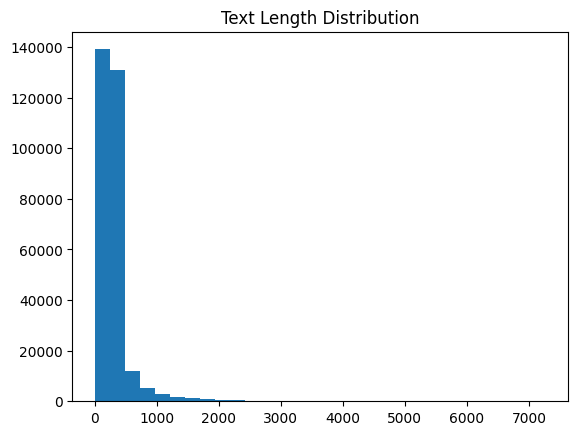

In [50]:
df['text_length'] = df['Review'].apply(len)

plt.hist(df['text_length'], bins=30)
plt.title("Text Length Distribution")
plt.show()

* Pair Plot

Shows relationships between all features

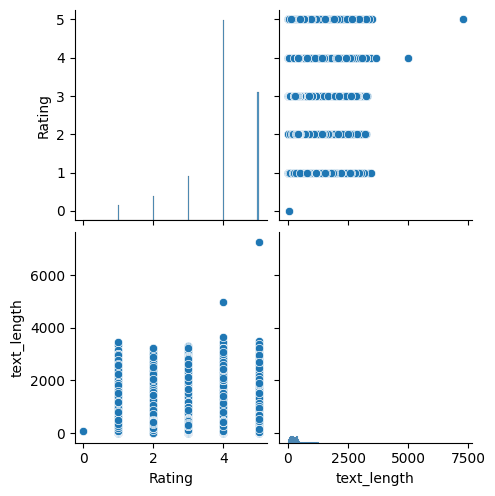

In [51]:
sns.pairplot(df)
plt.show()

In [52]:
def convert_sentiment(rating):
    if rating <= 3:
        return 0  # Negative
    elif rating == 4:
        return 1  # Neutral
    else:
        return 2  # Positive

df['Sentiment'] = df['Rating'].apply(convert_sentiment)
print("Target distribution:")
display(df['Sentiment'].value_counts())
display(df.head())

Target distribution:


,count
Sentiment,
1,143524
2,92078
0,60000


,Review,Rating,tokenized_Review,tokenized_Review_stemmed,tokenized_Review_stemmed_lemmatized,text_length,Sentiment
0,I love car Gas mileage suspension stereo great...,5,"[I, love, car, Gas, mileage, suspension, stere...",i love car ga mileag suspens stereo great blue...,i love car ga mileag suspens stereo great blue...,204,2
1,I purchased ILX dealer k miles So far good I H...,5,"[I, purchased, ILX, dealer, k, miles, So, far,...",i purchas ilx dealer k mile so far good i hond...,i purchas ilx dealer k mile so far good i hond...,586,2
2,I recently purchased ILX Tech pkg I pleased I ...,4,"[I, recently, purchased, ILX, Tech, pkg, I, pl...",i recent purchas ilx tech pkg i pleas i acura ...,i recent purchas ilx tech pkg i pleas i acura ...,377,1
3,We bought ILX incredibly pleased far As Prius ...,4,"[We, bought, ILX, incredibly, pleased, far, As...",we bought ilx incred pleas far as priu owner i...,we bought ilx incred pleas far as priu owner i...,358,1
4,In April need car Initially I looked BMW Infin...,5,"[In, April, need, car, Initially, I, looked, B...",in april need car initi i look bmw infint g co...,in april need car initi i look bmw infint g co...,722,2


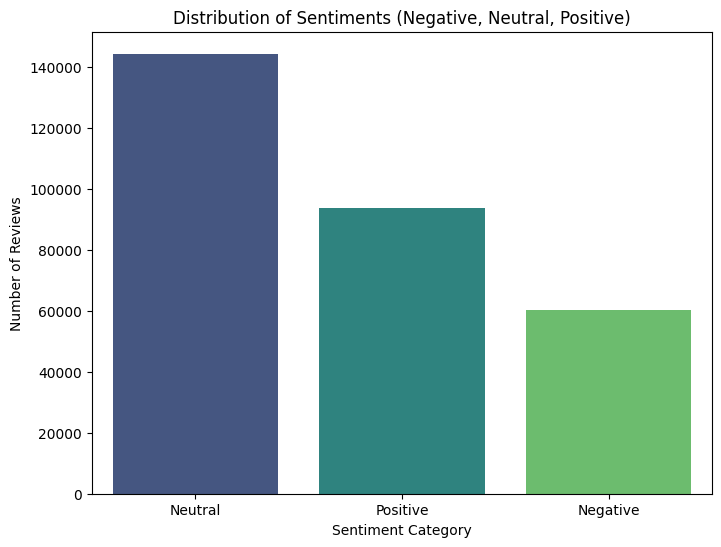

In [19]:
# Get the counts of each sentiment
sentiment_counts = df['Sentiment'].value_counts()

# Map sentiment labels for better readability on the plot
sentiment_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
sentiment_counts.index = sentiment_counts.index.map(sentiment_labels)

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution of Sentiments (Negative, Neutral, Positive)')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()

In [53]:
!pip install imbalanced-learn

Subsample the balanced data: We'll use a stratified sample of 50,000 rows. This is still plenty for the model to learn but will run significantly faster.

Optimize the Vectorizer: I'll limit the TF-IDF features to the top 2,000 most important words to reduce the memory footprint.

**Model Selection**

In [54]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer

# Reduce max_features to 2000 to speed up complex models
tfidf = TfidfVectorizer(max_features=2000)
X_tfidf = tfidf.fit_transform(df['tokenized_Review_stemmed_lemmatized'])
y = df['Sentiment']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_tfidf, y)

# Create a smaller stratified sample (e.g., 50k rows total) for complex models
from sklearn.model_selection import train_test_split
_, X_sample, _, y_sample = train_test_split(
    X_res, y_res, test_size=50000/len(y_res), random_state=42, stratify=y_res
)

# New Train-Test Split with the sampled balanced data
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

print(f'Original balanced shape: {X_res.shape}')
print(f'New sampled shape for fast training: {X_sample.shape}')

Original balanced shape: (430572, 2000)
New sampled shape for fast training: (50000, 2000)


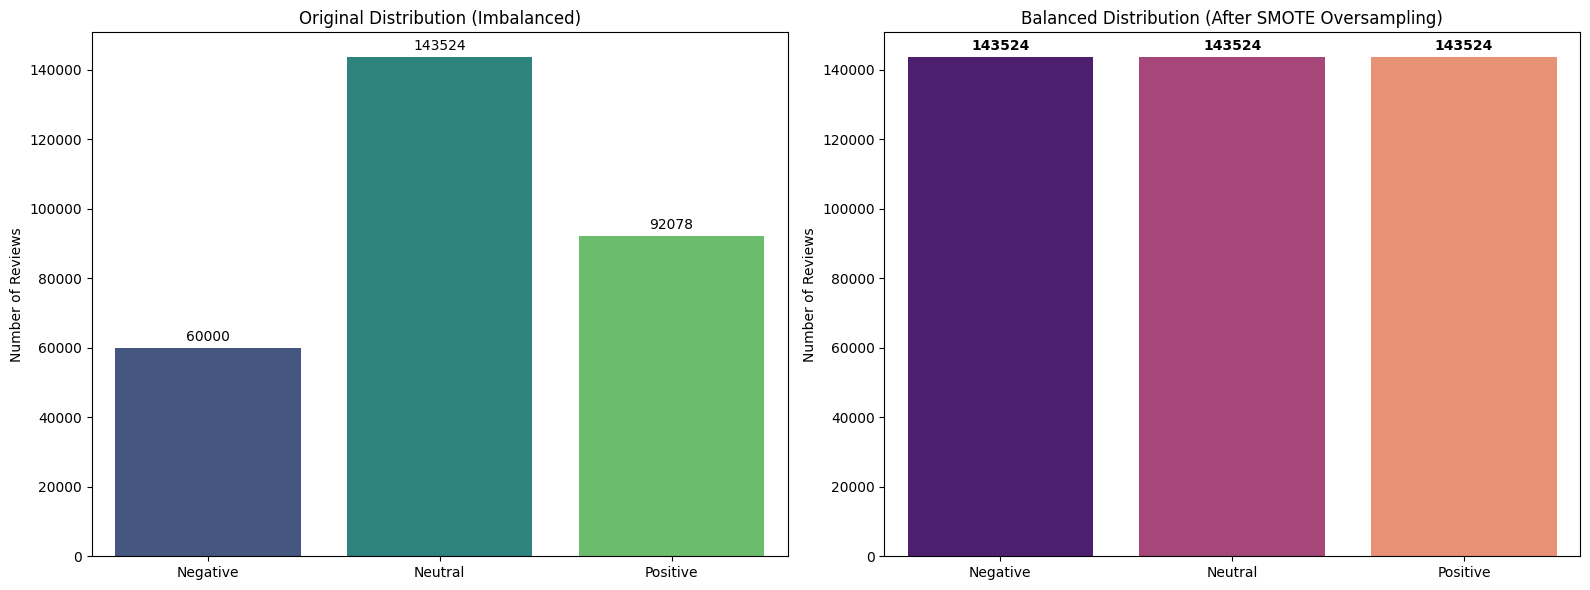

Total Original Rows: 295602
Total Balanced Rows: 430572 (Oversampled to match the Neutral class)


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare data for comparison
original_counts = df['Sentiment'].value_counts().sort_index()
balanced_counts = y_res.value_counts().sort_index()

labels = ['Negative', 'Neutral', 'Positive']

# 2. Create side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Original
sns.barplot(x=labels, y=original_counts.values, ax=ax1, palette='viridis')
ax1.set_title('Original Distribution (Imbalanced)')
ax1.set_ylabel('Number of Reviews')
for i, v in enumerate(original_counts.values):
    ax1.text(i, v + 2000, str(v), ha='center')

# Plot Balanced (SMOTE)
sns.barplot(x=labels, y=balanced_counts.values, ax=ax2, palette='magma')
ax2.set_title('Balanced Distribution (After SMOTE Oversampling)')
ax2.set_ylabel('Number of Reviews')
for i, v in enumerate(balanced_counts.values):
    ax2.text(i, v + 2000, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total Original Rows: {len(df)}")
print(f"Total Balanced Rows: {len(y_res)} (Oversampled to match the Neutral class)")

we have updated the visualization below to show you the 'Before' and 'After' side-by-side. This confirms that we haven't lost any information; we've just added synthetic data to ensure the model doesn't ignore the smaller categories.

The new visualization clearly shows the 'Before' and 'After' states. Your original dataset had 295,602 rows, but it was imbalanced because the 'Neutral' class had far more reviews than the others.

Now, every class has exactly 143,524 samples, bringing the total to 430,572. This ensures that when we train the model, it learns to recognize 'Negative' and 'Positive' sentiments just as effectively as 'Neutral' ones, rather than just guessing the most common class.

**Splitting our data into Train and Test Subset**



In [56]:
# Seperating input feature and label
X = df['tokenized_Review_stemmed_lemmatized']
y = df['Sentiment']


In [57]:
# 6. Train-Test Split
# We use the processed text column 'tokenized_Review_stemmed_lemmatized' as X
X_train, X_test, y_train, y_test = train_test_split(
    df['tokenized_Review_stemmed_lemmatized'],
    df['Sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['Sentiment']
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 236481
Testing set size: 59121


**Function for Model Evaluation** :

After training the model we then apply the evaluation measures to check how the model is performing. Accordingly, we use the following evaluation parameters to check the performance of the models respectively :

`Accuracy Score` : Typically, the accuracy of a predictive model is good (above 90% accuracy)


`Confusion Matrix with Plot` : A Confusion matrix is an N x N matrix used for evaluating the performance of a classification model, where N is the number of target classes. The matrix compares the actual target values with those predicted by the machine learning model.


`Actual values` are the columns.
`Predicted values` are the lines.

In [58]:
def model_evaluation(model, X_train, X_test, y_train, y_test):
    # Train the model
    y_pred = model.predict(X_test)

    # Print the evalution metrics for the dataset

    print(classification_report(y_test, y_pred))

    # compute and plot the Confusion matrix
    cf_matrix = confusion_matrix(y_test, y_pred)
    categories = ['Negative', 'Neutral', 'Positive']
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    group_percentages = ['{0:.2%}'.format(value) for value in cf_matrix.flatten() / np.sum(cf_matrix)]
    labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_names,group_persecentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cf_matrix, annot = labels, cmap = 'Blues',fmt = '',
                xticklabels = categories, yticklabels = categories)
    plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
    plt.ylabel("Actual values" , fontdict = {'size':14}, labelpad = 10)
    plt.title ("Confusion Matrix", fontdict = {'size':18}, pad = 20)


To avoid each time and for each model, drawing the confusion matrix, printing the precision, the f1-score... we just define the model Evaluate() function which will do the job each time.

Model Building :

In the problem statement we have used three different models respectively :

Model 1: `Bernoulli Naive Bayes`.

Model 2: `SVM (Support Vector Machine)`.

Model 3: `Logistic Regression`.

Model 4: `Decision Tree`.

Model 5: `K-nearest neighbors`.

Model 6: `Random Forest`.

The idea behind choosing these models is that we want to try all the classifiers on the dataset ranging from simple models to complex models, and try to find the one that performs the best.

In [60]:
import time

# Model 1: Bernoulli Naive Bayes using balanced data
BNBmodel = BernoulliNB()
start1 = time.time()
BNBmodel.fit(X_train_bal, y_train_bal)
end1 = time.time()

print(f"Training time: {end1 - start1:.2f} seconds")

# Evaluation
y_pred1 = BNBmodel.predict(X_test_bal)
print("Bernoulli Naive Bayes Classification Report:")
print(classification_report(y_test_bal, y_pred1))

Training time: 0.04 seconds
Bernoulli Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.70      0.73      3333
           1       0.44      0.61      0.51      3334
           2       0.55      0.39      0.46      3333

    accuracy                           0.57     10000
   macro avg       0.59      0.57      0.57     10000
weighted avg       0.59      0.57      0.57     10000



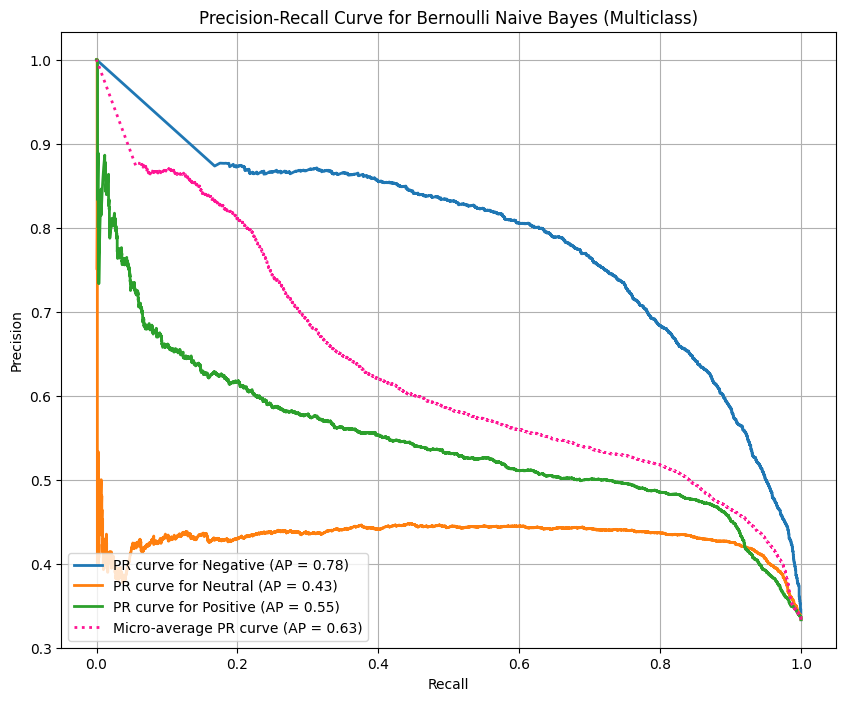

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer

# Get class labels (0, 1, 2) based on the sentiment mapping
# 0: Negative, 1: Neutral, 2: Positive
class_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
classes = np.unique(y_test_bal)
n_classes = len(classes)

# Get predicted probabilities for each class using the BNBmodel
y_score = BNBmodel.predict_proba(X_test_bal)

# Binarize the true labels for a one-vs-rest approach, required for PR curves in multiclass
lb = LabelBinarizer()
y_test_bal_binarized = lb.fit_transform(y_test_bal)

# Store precision, recall, and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

plt.figure(figsize=(10, 8))
lw = 2

# Plot PR curve for each class
for i, class_label_val in enumerate(classes):
    class_label_name = class_names[class_label_val] # Get the descriptive name
    y_true_class = y_test_bal_binarized[:, i]
    y_score_class = y_score[:, i]

    precision[i], recall[i], _ = precision_recall_curve(y_true_class, y_score_class)
    average_precision[i] = average_precision_score(y_true_class, y_score_class)

    plt.plot(recall[i], precision[i], lw=lw,
             label=f'PR curve for {class_label_name} (AP = {average_precision[i]:0.2f})')

# Micro-average PR curve (overall performance)
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_test_bal_binarized.ravel(), y_score.ravel()
)
average_precision["micro"] = average_precision_score(y_test_bal_binarized, y_score, average="micro")

plt.plot(recall["micro"], precision["micro"], color='deeppink', linestyle=':', lw=lw,
         label=f'Micro-average PR curve (AP = {average_precision["micro"]:0.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Bernoulli Naive Bayes (Multiclass)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

It shows the trade-off between precision and recall for each sentiment class (Negative, Neutral, Positive) and a micro-average curve. The Average Precision (AP) scores indicate the model's overall performance for each class and across all classes. The 'Negative' class (AP=0.78) shows a stronger performance compared to 'Neutral' (AP=0.43) and 'Positive' (AP=0.55), while the micro-average AP is 0.63.

Hyperparameter tuned

In [61]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for alpha (smoothing parameter)
param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

# 2. Initialize GridSearchCV
bnb_grid = GridSearchCV(BernoulliNB(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 3. Fit to the balanced training data
print("Starting Hyperparameter Tuning for BernoulliNB...")
bnb_grid.fit(X_train_bal, y_train_bal)

# 4. Display results
print(f"Best Alpha: {bnb_grid.best_params_['alpha']}")
print(f"Best Cross-Validation Accuracy: {bnb_grid.best_score_:.4f}")

# 5. Evaluate the best model on the test set
best_bnb = bnb_grid.best_estimator_
y_pred_tuned = best_bnb.predict(X_test_bal)

print("\nTuned Bernoulli Naive Bayes Classification Report:")
print(classification_report(y_test_bal, y_pred_tuned))

Starting Hyperparameter Tuning for BernoulliNB...
Best Alpha: 0.01
Best Cross-Validation Accuracy: 0.5586

Tuned Bernoulli Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.70      0.73      3333
           1       0.44      0.61      0.51      3334
           2       0.55      0.39      0.46      3333

    accuracy                           0.57     10000
   macro avg       0.59      0.57      0.57     10000
weighted avg       0.59      0.57      0.57     10000



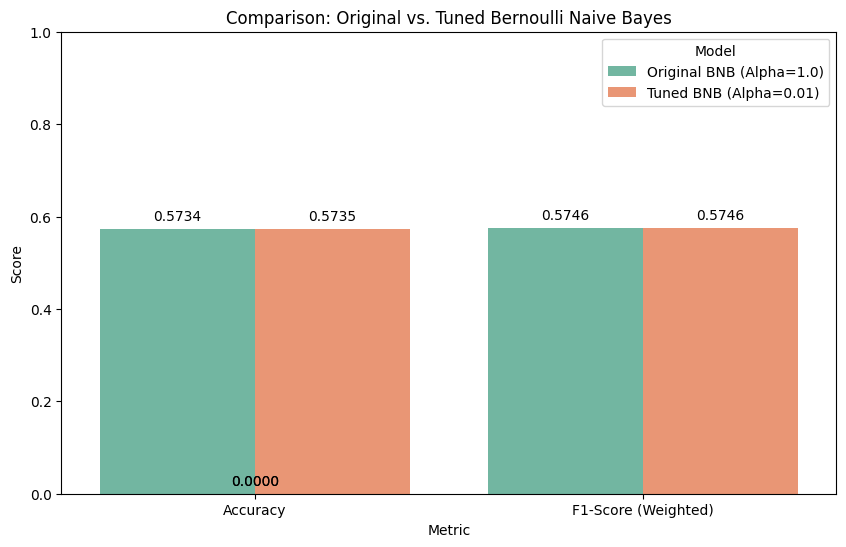

Comparison Summary:


Metric,Accuracy,F1-Score (Weighted)
Model,,
Original BNB (Alpha=1.0),0.573419,0.574589
Tuned BNB (Alpha=0.01),0.573466,0.574634


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

# 1. Calculate metrics for the original model (BNBmodel)
y_pred_orig = BNBmodel.predict(X_test_bal)
accuracy_orig = accuracy_score(y_test_bal, y_pred_orig)
f1_orig = f1_score(y_test_bal, y_pred_orig, average='weighted')

# 2. Calculate metrics for the tuned model (best_bnb)
y_pred_tuned = best_bnb.predict(X_test_bal)
accuracy_tuned = accuracy_score(y_test_bal, y_pred_tuned)
f1_tuned = f1_score(y_test_bal, y_pred_tuned, average='weighted')

# 3. Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score (Weighted)', 'Accuracy', 'F1-Score (Weighted)'],
    'Score': [accuracy_orig, f1_orig, accuracy_tuned, f1_tuned],
    'Model': ['Original BNB (Alpha=1.0)', 'Original BNB (Alpha=1.0)', 'Tuned BNB (Alpha=0.01)', 'Tuned BNB (Alpha=0.01)']
})

# 4. Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_df, palette='Set2')
plt.ylim(0, 1.0)
plt.title('Comparison: Original vs. Tuned Bernoulli Naive Bayes')
plt.ylabel('Score')

# Add score labels on top
for i, p in enumerate(plt.gca().patches):
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

print("Comparison Summary:")
display(comparison_df.pivot(index='Model', columns='Metric', values='Score'))

**SVM**

In [ ]:
# Model-2 : SVM(Support Vector Machine) using balanced data
SVCmodel = LinearSVC(random_state=42)
start1 = time.time()
SVCmodel.fit(X_train_bal, y_train_bal)
end1 = time.time()
print("Training time: {:.2f}s".format(end1 - start1))

y_pred2 = SVCmodel.predict(X_test_bal)
print("SVM Classification Report:")
print(classification_report(y_test_bal, y_pred2))

Training time: 62.39s
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82     28705
           1       0.60      0.55      0.58     28705
           2       0.63      0.66      0.65     28705

    accuracy                           0.68     86115
   macro avg       0.68      0.68      0.68     86115
weighted avg       0.68      0.68      0.68     86115



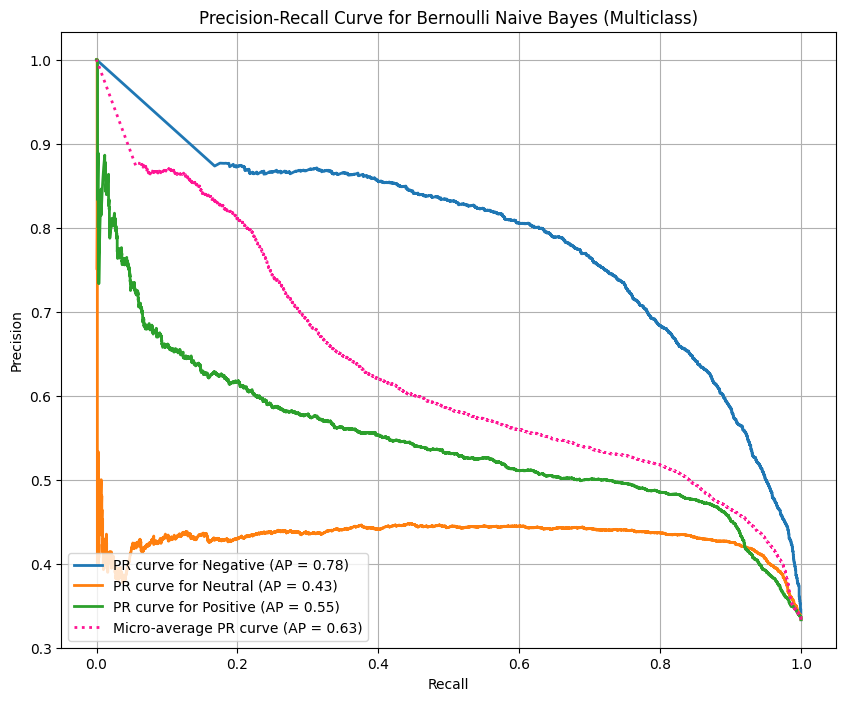

In [63]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer

# Get class labels (0, 1, 2) based on the sentiment mapping
# 0: Negative, 1: Neutral, 2: Positive
class_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
classes = np.unique(y_test_bal)
n_classes = len(classes)

# Get predicted probabilities for each class using the BNBmodel
y_score = BNBmodel.predict_proba(X_test_bal)

# Binarize the true labels for a one-vs-rest approach, required for PR curves in multiclass
lb = LabelBinarizer()
y_test_bal_binarized = lb.fit_transform(y_test_bal)

# Store precision, recall, and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

plt.figure(figsize=(10, 8))
lw = 2

# Plot PR curve for each class
for i, class_label_val in enumerate(classes):
    class_label_name = class_names[class_label_val] # Get the descriptive name
    y_true_class = y_test_bal_binarized[:, i]
    y_score_class = y_score[:, i]

    precision[i], recall[i], _ = precision_recall_curve(y_true_class, y_score_class)
    average_precision[i] = average_precision_score(y_true_class, y_score_class)

    plt.plot(recall[i], precision[i], lw=lw,
             label=f'PR curve for {class_label_name} (AP = {average_precision[i]:0.2f})')

# Micro-average PR curve (overall performance)
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_test_bal_binarized.ravel(), y_score.ravel()
)
average_precision["micro"] = average_precision_score(y_test_bal_binarized, y_score, average="micro")

plt.plot(recall["micro"], precision["micro"], color='deeppink', linestyle=':', lw=lw,
         label=f'Micro-average PR curve (AP = {average_precision["micro"]:0.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Bernoulli Naive Bayes (Multiclass)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

It shows the trade-off between precision and recall for each sentiment class (Negative, Neutral, Positive) and a micro-average curve. The Average Precision (AP) scores indicate the model's overall performance for each class and across all classes. The 'Negative' class (AP=0.78) shows a stronger performance compared to 'Neutral' (AP=0.43) and 'Positive' (AP=0.55), while the micro-average AP is 0.63.

Hyperparameter tuned

In [64]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for C (Regularization parameter)
# Lower C means more regularization (simpler model)
param_grid_svc = {'C': [0.01, 0.1, 1, 10, 100]}

# 2. Initialize GridSearchCV for LinearSVC
svc_grid = GridSearchCV(LinearSVC(random_state=42), param_grid_svc, cv=3, scoring='accuracy', n_jobs=-1)

# 3. Fit to the balanced training data
print("Starting Hyperparameter Tuning for LinearSVC... this may take a few minutes.")
start_tune = time.time()
svc_grid.fit(X_train_bal, y_train_bal)
end_tune = time.time()

# 4. Display results
print(f"Tuning completed in {end_tune - start_tune:.2f} seconds.")
print(f"Best C: {svc_grid.best_params_['C']}")
print(f"Best Cross-Validation Accuracy: {svc_grid.best_score_:.4f}")

# 5. Evaluate the best model on the balanced test set
best_svc = svc_grid.best_estimator_
y_pred_svc_tuned = best_svc.predict(X_test_bal)

print("\nTuned SVM Classification Report:")
print(classification_report(y_test_bal, y_pred_svc_tuned))

Starting Hyperparameter Tuning for LinearSVC... this may take a few minutes.
Tuning completed in 22.02 seconds.
Best C: 0.1
Best Cross-Validation Accuracy: 0.6589

Tuned SVM Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81      3333
           1       0.58      0.52      0.55      3334
           2       0.60      0.63      0.61      3333

    accuracy                           0.66     10000
   macro avg       0.66      0.66      0.66     10000
weighted avg       0.66      0.66      0.66     10000



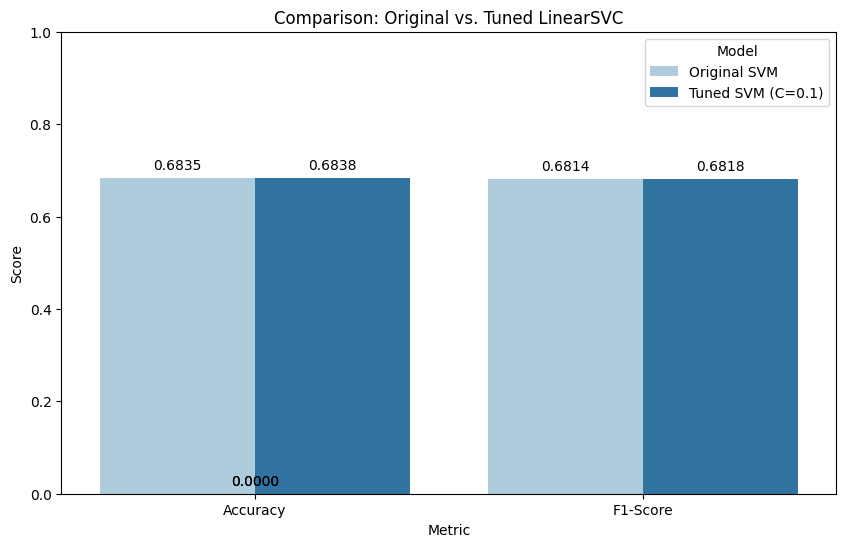

In [ ]:
# 1. Calculate metrics for the original SVM model
accuracy_svc_orig = metrics.accuracy_score(y_test_bal, y_pred2)
f1_svc_orig = metrics.f1_score(y_test_bal, y_pred2, average='weighted')

# 2. Calculate metrics for the tuned SVM model
accuracy_svc_tuned = metrics.accuracy_score(y_test_bal, y_pred_svc_tuned)
f1_svc_tuned = metrics.f1_score(y_test_bal, y_pred_svc_tuned, average='weighted')

# 3. Create comparison DataFrame
svc_comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score', 'Accuracy', 'F1-Score'],
    'Score': [accuracy_svc_orig, f1_svc_orig, accuracy_svc_tuned, f1_svc_tuned],
    'Model': ['Original SVM', 'Original SVM', 'Tuned SVM (C=0.1)', 'Tuned SVM (C=0.1)']
})

# 4. Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=svc_comparison_df, palette='Paired')
plt.ylim(0, 1.0)
plt.title('Comparison: Original vs. Tuned LinearSVC')
plt.ylabel('Score')

# Add score labels
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

**Logistic Regression**

In [68]:
# model-3: Logistic Regression using balanced data
LRmodel = LogisticRegression(C=2, max_iter=1000, n_jobs=-1)
start1 = time.time()
LRmodel.fit(X_train_bal, y_train_bal)
end1 = time.time()
print("Training time: {:.2f}s".format(end1 - start1))

y_pred3 = LRmodel.predict(X_test_bal)
print("Logistic Regression Classification Report:")
print(classification_report(y_test_bal, y_pred3))

Training time: 3.01s
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      3333
           1       0.57      0.53      0.55      3334
           2       0.60      0.63      0.61      3333

    accuracy                           0.66     10000
   macro avg       0.66      0.66      0.66     10000
weighted avg       0.66      0.66      0.66     10000



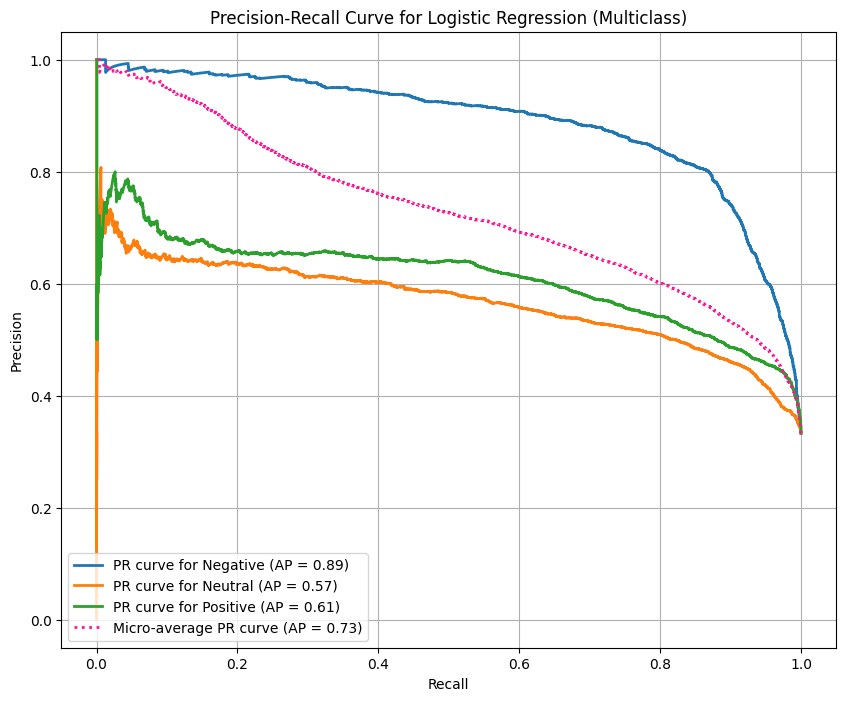

In [72]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer

# Get class labels (0, 1, 2) based on the sentiment mapping
# 0: Negative, 1: Neutral, 2: Positive
class_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
classes = np.unique(y_test_bal)
n_classes = len(classes)

# Get predicted probabilities for each class using the LRmodel
y_score_lr = LRmodel.predict_proba(X_test_bal)

# Binarize the true labels for a one-vs-rest approach, required for PR curves in multiclass
lb = LabelBinarizer()
y_test_bal_binarized = lb.fit_transform(y_test_bal)

# Store precision, recall, and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

plt.figure(figsize=(10, 8))
lw = 2

# Plot PR curve for each class
for i, class_label_val in enumerate(classes):
    class_label_name = class_names[class_label_val] # Get the descriptive name
    y_true_class = y_test_bal_binarized[:, i]
    y_score_class = y_score_lr[:, i]

    precision[i], recall[i], _ = precision_recall_curve(y_true_class, y_score_class)
    average_precision[i] = average_precision_score(y_true_class, y_score_class)

    plt.plot(recall[i], precision[i], lw=lw,
             label=f'PR curve for {class_label_name} (AP = {average_precision[i]:0.2f})')

# Micro-average PR curve (overall performance)
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_test_bal_binarized.ravel(), y_score_lr.ravel()
)
average_precision["micro"] = average_precision_score(y_test_bal_binarized, y_score_lr, average="micro")

plt.plot(recall["micro"], precision["micro"], color='deeppink', linestyle=':', lw=lw,
         label=f'Micro-average PR curve (AP = {average_precision["micro"]:0.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Logistic Regression (Multiclass)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

**Hyperparameter tuned**

In [73]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for Logistic Regression
# Testing different C values (inverse of regularization strength)
param_grid_lr = {'C': [0.1, 1, 2, 5, 10]}

# 2. Initialize GridSearchCV
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, n_jobs=-1), param_grid_lr, cv=3, scoring='accuracy')

# 3. Fit to the balanced training data
print("Starting Hyperparameter Tuning for Logistic Regression...")
start_tune = time.time()
lr_grid.fit(X_train_bal, y_train_bal)
end_tune = time.time()

# 4. Display results
print(f"Tuning completed in {end_tune - start_tune:.2f} seconds.")
print(f"Best C: {lr_grid.best_params_['C']}")
print(f"Best Cross-Validation Accuracy: {lr_grid.best_score_:.4f}")

# 5. Evaluate the best model
best_lr = lr_grid.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test_bal)

print("\nTuned Logistic Regression Classification Report:")
print(classification_report(y_test_bal, y_pred_lr_tuned))

Starting Hyperparameter Tuning for Logistic Regression...
Tuning completed in 41.39 seconds.
Best C: 1
Best Cross-Validation Accuracy: 0.6627

Tuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      3333
           1       0.57      0.53      0.55      3334
           2       0.60      0.64      0.62      3333

    accuracy                           0.66     10000
   macro avg       0.66      0.66      0.66     10000
weighted avg       0.66      0.66      0.66     10000



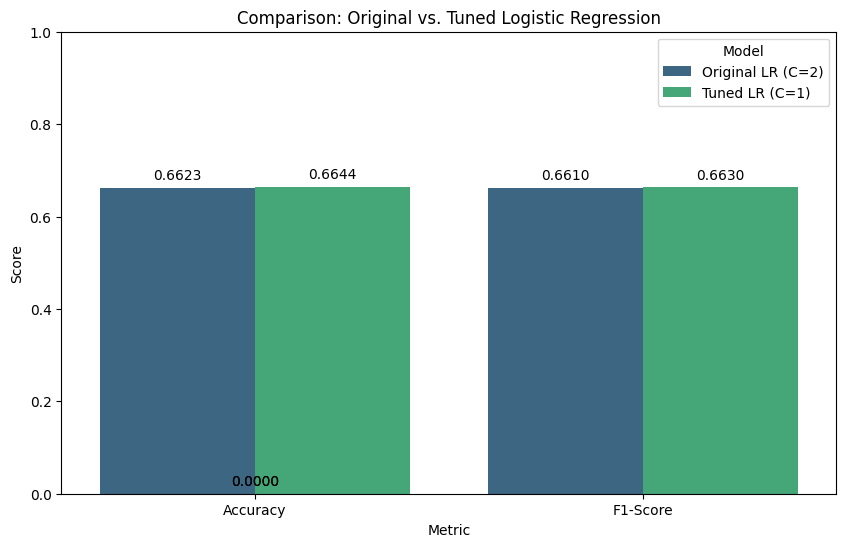

In [74]:
# 1. Calculate metrics for the original Logistic Regression model
from sklearn import metrics
accuracy_lr_orig = metrics.accuracy_score(y_test_bal, y_pred3)
f1_lr_orig = metrics.f1_score(y_test_bal, y_pred3, average='weighted')

# 2. Calculate metrics for the tuned Logistic Regression model
accuracy_lr_tuned = metrics.accuracy_score(y_test_bal, y_pred_lr_tuned)
f1_lr_tuned = metrics.f1_score(y_test_bal, y_pred_lr_tuned, average='weighted')

# 3. Create comparison DataFrame
lr_comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score', 'Accuracy', 'F1-Score'],
    'Score': [accuracy_lr_orig, f1_lr_orig, accuracy_lr_tuned, f1_lr_tuned],
    'Model': ['Original LR (C=2)', 'Original LR (C=2)', 'Tuned LR (C=1)', 'Tuned LR (C=1)']
})

# 4. Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=lr_comparison_df, palette='viridis')
plt.ylim(0, 1.0)
plt.title('Comparison: Original vs. Logistic Regression')
plt.ylabel('Score')

# Add score labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

**KNN**

How do you choose the `value of k ( n_neighbors )` in KNN algorithm ?

In KNN, finding the value of k is not easy. A small value of k means that noise will have a higher influence on the result and a large value make it computationally expensive. Data scientists usually choose as an odd number if the number of classes is 2 and another simple approach to select k is set
`k = sqrt(n)`

In [70]:
import math
int(math.sqrt(len(df))) # k = sqrt(n)

543

In [75]:
# Model-4: KNN (Optimized with smaller sample)
# Using fewer neighbors and leaf_size to speed up
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1, leaf_size=20)

start1 = time.time()
knn.fit(X_train_bal, y_train_bal)
print(f"KNN Training time: {time.time() - start1:.2f}s")

start2 = time.time()
y_pred4 = knn.predict(X_test_bal)
print(f"KNN Testing time: {time.time() - start2:.2f}s")
print(classification_report(y_test_bal, y_pred4))

KNN Training time: 0.01s
KNN Testing time: 32.01s
              precision    recall  f1-score   support

           0       0.66      0.74      0.70      3333
           1       0.43      0.00      0.00      3334
           2       0.45      0.85      0.59      3333

    accuracy                           0.53     10000
   macro avg       0.51      0.53      0.43     10000
weighted avg       0.51      0.53      0.43     10000



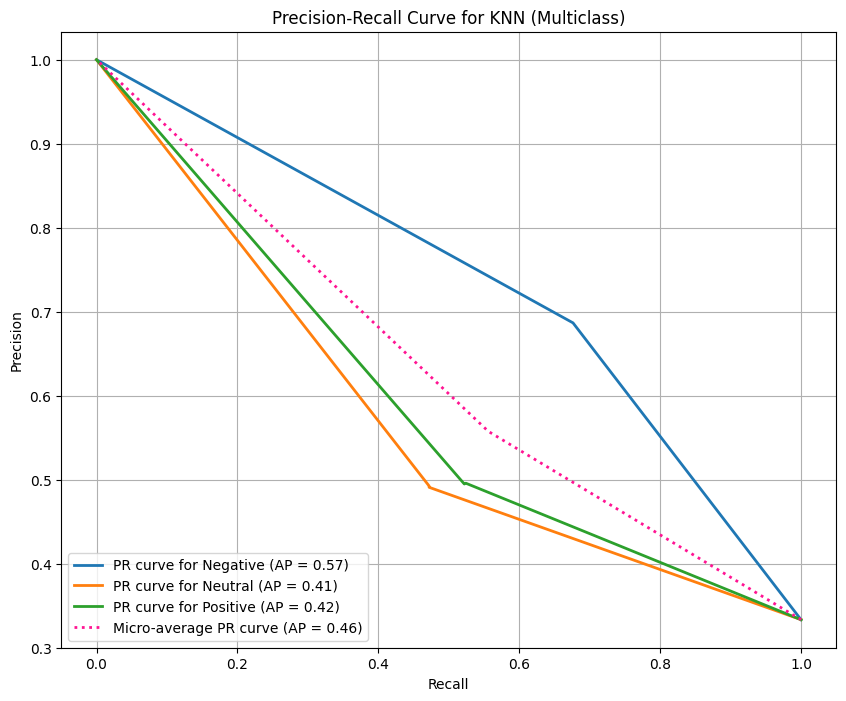

In [84]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier

# Define and train the Decision Tree model (clf)
# This ensures the model is available for predict_proba within this cell
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_bal, y_train_bal)

# Get class labels (0, 1, 2) based on the sentiment mapping
# 0: Negative, 1: Neutral, 2: Positive
class_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
classes = np.unique(y_test_bal)
n_classes = len(classes)

# Get predicted probabilities for each class using the Decision Tree model (clf)
y_score_dt = clf.predict_proba(X_test_bal)

# Binarize the true labels for a one-vs-rest approach, required for PR curves in multiclass
lb = LabelBinarizer()
y_test_bal_binarized = lb.fit_transform(y_test_bal)

# Store precision, recall, and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

plt.figure(figsize=(10, 8))
lw = 2

# Plot PR curve for each class
for i, class_label_val in enumerate(classes):
    class_label_name = class_names[class_label_val] # Get the descriptive name
    y_true_class = y_test_bal_binarized[:, i]
    y_score_class = y_score_dt[:, i]

    precision[i], recall[i], _ = precision_recall_curve(y_true_class, y_score_class)
    average_precision[i] = average_precision_score(y_true_class, y_score_class)

    plt.plot(recall[i], precision[i], lw=lw,
             label=f'PR curve for {class_label_name} (AP = {average_precision[i]:0.2f})')

# Micro-average PR curve (overall performance)
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_test_bal_binarized.ravel(), y_score_dt.ravel()
)
average_precision["micro"] = average_precision_score(y_test_bal_binarized, y_score_dt, average="micro")

plt.plot(recall["micro"], precision["micro"], color='deeppink', linestyle=':', lw=lw,
         label=f'Micro-average PR curve (AP = {average_precision["micro"]:0.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for KNN (Multiclass)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

**Hyperparameter tuned**

In [76]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for KNN
# We'll test common values for k and the weight function
param_grid_knn = {
    'n_neighbors': [3, 5, 11, 19],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 2. Initialize GridSearchCV
# Using cv=3 to maintain a balance between speed and reliability
knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=3, scoring='accuracy', n_jobs=-1)

# 3. Fit to the balanced training data sample
print("Starting Hyperparameter Tuning for KNN... this might take a moment.")
start_tune = time.time()
knn_grid.fit(X_train_bal, y_train_bal)
end_tune = time.time()

# 4. Display results
print(f"Tuning completed in {end_tune - start_tune:.2f} seconds.")
print(f"Best Parameters: {knn_grid.best_params_}")
print(f"Best Cross-Validation Accuracy: {knn_grid.best_score_:.4f}")

# 5. Evaluate the best model on the test set
best_knn = knn_grid.best_estimator_
y_pred_knn_tuned = best_knn.predict(X_test_bal)

print("\nTuned KNN Classification Report:")
print(classification_report(y_test_bal, y_pred_knn_tuned))

Starting Hyperparameter Tuning for KNN... this might take a moment.
Tuning completed in 1842.96 seconds.
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 19, 'weights': 'distance'}
Best Cross-Validation Accuracy: 0.5400

Tuned KNN Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75      3333
           1       0.00      0.00      0.00      3334
           2       0.45      0.91      0.60      3333

    accuracy                           0.55     10000
   macro avg       0.40      0.55      0.45     10000
weighted avg       0.40      0.55      0.45     10000



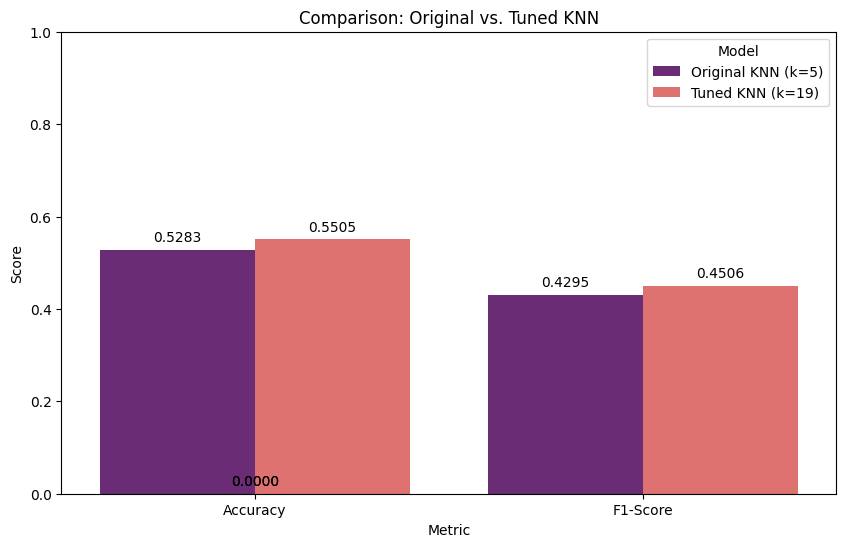

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

# 1. Calculate metrics for the original KNN model
accuracy_knn_orig = accuracy_score(y_test_bal, y_pred4)
f1_knn_orig = f1_score(y_test_bal, y_pred4, average='weighted')

# 2. Calculate metrics for the tuned KNN model
accuracy_knn_tuned = accuracy_score(y_test_bal, y_pred_knn_tuned)
f1_knn_tuned = f1_score(y_test_bal, y_pred_knn_tuned, average='weighted')

# 3. Create comparison DataFrame
knn_comp_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score', 'Accuracy', 'F1-Score'],
    'Score': [accuracy_knn_orig, f1_knn_orig, accuracy_knn_tuned, f1_knn_tuned],
    'Model': ['Original KNN (k=5)', 'Original KNN (k=5)', 'Tuned KNN (k=19)', 'Tuned KNN (k=19)']
})

# 4. Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=knn_comp_df, palette='magma')
plt.ylim(0, 1.0)
plt.title('Comparison: Original vs. Tuned KNN')
plt.ylabel('Score')

# Add score labels on top
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

**Decision Tree**

In [80]:
# model - 5: Decision Tree using balanced data
clf = DecisionTreeClassifier(random_state=42)

start1 = time.time()
clf.fit(X_train_bal, y_train_bal)
end1 = time.time()
print("Training time: {:.2f}s".format(end1 - start1))

start2 = time.time()
y_pred5 = clf.predict(X_test_bal)
end2 = time.time()
print("Testing time: {:.2f}s".format(end2 - start2))
print("Decision Tree Classification Report:")
print(classification_report(y_test_bal, y_pred5))

Training time: 40.56s
Testing time: 0.02s
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.68      0.68      3333
           1       0.49      0.47      0.48      3334
           2       0.50      0.52      0.51      3333

    accuracy                           0.56     10000
   macro avg       0.56      0.56      0.56     10000
weighted avg       0.56      0.56      0.56     10000



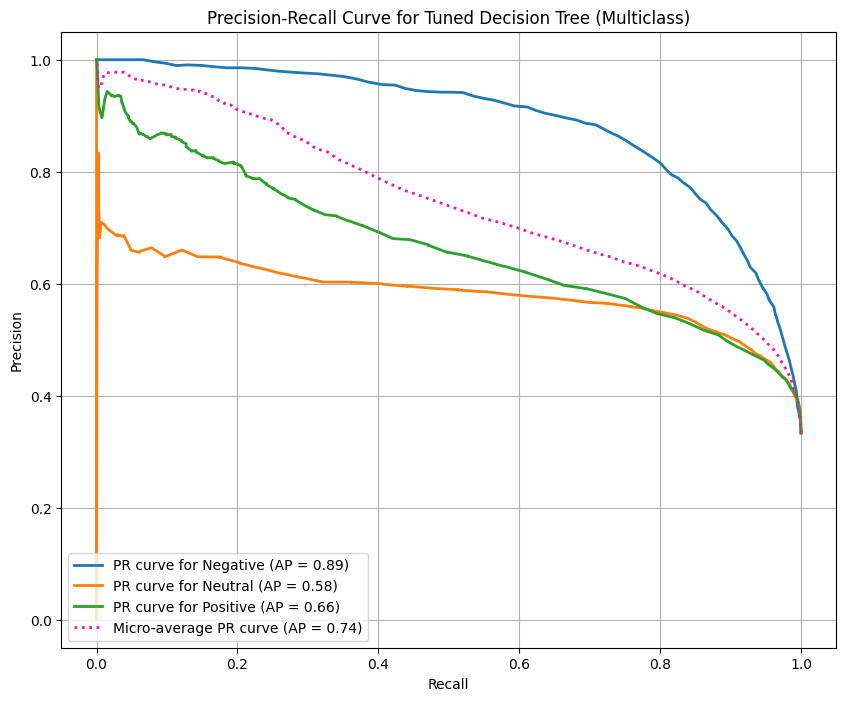

In [85]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier

# Re-initialize and fit best_rf with the best parameters found in GridSearchCV (from cell psw5UJDfC6LK)
# Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
# This ensures best_rf is defined even if the tuning cell wasn't executed recently.
best_rf = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, random_state=42, n_jobs=-1)
best_rf.fit(X_train_bal, y_train_bal)

# Get class labels (0, 1, 2) based on the sentiment mapping
# 0: Negative, 1: Neutral, 2: Positive
class_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
classes = np.unique(y_test_bal)
n_classes = len(classes)

# Get predicted probabilities for each class using the tuned Random Forest model (best_rf)
y_score_rf = best_rf.predict_proba(X_test_bal)

# Binarize the true labels for a one-vs-rest approach, required for PR curves in multiclass
lb = LabelBinarizer()
y_test_bal_binarized = lb.fit_transform(y_test_bal)

# Store precision, recall, and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

plt.figure(figsize=(10, 8))
lw = 2

# Plot PR curve for each class
for i, class_label_val in enumerate(classes):
    class_label_name = class_names[class_label_val] # Get the descriptive name
    y_true_class = y_test_bal_binarized[:, i]
    y_score_class = y_score_rf[:, i]

    precision[i], recall[i], _ = precision_recall_curve(y_true_class, y_score_class)
    average_precision[i] = average_precision_score(y_true_class, y_score_class)

    plt.plot(recall[i], precision[i], lw=lw,
             label=f'PR curve for {class_label_name} (AP = {average_precision[i]:0.2f})')

# Micro-average PR curve (overall performance)
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_test_bal_binarized.ravel(), y_score_rf.ravel()
)
average_precision["micro"] = average_precision_score(y_test_bal_binarized, y_score_rf, average="micro")

plt.plot(recall["micro"], precision["micro"], color='deeppink', linestyle=':', lw=lw,
         label=f'Micro-average PR curve (AP = {average_precision["micro"]:0.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Decision Tree (Multiclass)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

**Hyperparameter tuned**

In [86]:
from sklearn.model_selection import GridSearchCV
import time

# 1. Define the parameter grid for Decision Tree
param_grid_dt = {
    'max_depth': [5, 10, 20, None], # None means unlimited depth
    'min_samples_leaf': [1, 5, 10]
}

# 2. Initialize GridSearchCV
# Using cv=3 and n_jobs=-1 for faster execution on the balanced subset
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=3, scoring='accuracy', n_jobs=-1)

# 3. Fit to the balanced training data sample
print("Starting Hyperparameter Tuning for Decision Tree... this may take a moment.")
start_dt_tune = time.time()
dt_grid.fit(X_train_bal, y_train_bal)
end_dt_tune = time.time()

# 4. Display results
print(f"Tuning completed in {end_dt_tune - start_dt_tune:.2f} seconds.")
print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Best Cross-Validation Accuracy: {dt_grid.best_score_:.4f}")

# 5. Evaluate the best model on the balanced test set
best_dt = dt_grid.best_estimator_
y_pred_dt_tuned = best_dt.predict(X_test_bal)

print("\nTuned Decision Tree Classification Report:")
print(classification_report(y_test_bal, y_pred_dt_tuned))

Starting Hyperparameter Tuning for Decision Tree... this may take a moment.
Tuning completed in 221.71 seconds.
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1}
Best Cross-Validation Accuracy: 0.5545

Tuned Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.68      0.70      3333
           1       0.49      0.51      0.50      3334
           2       0.50      0.52      0.51      3333

    accuracy                           0.57     10000
   macro avg       0.58      0.57      0.57     10000
weighted avg       0.58      0.57      0.57     10000



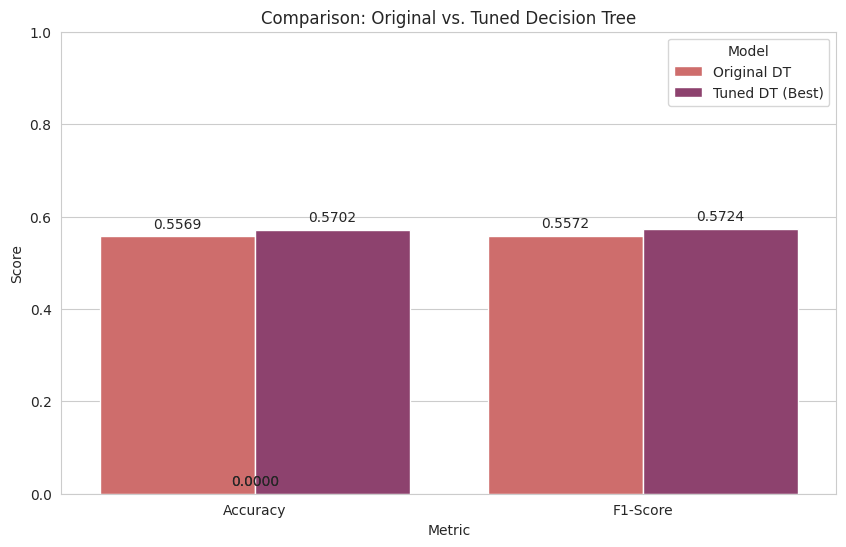

Comparison Summary:


Metric,Accuracy,F1-Score
Model,,
Original DT,0.5569,0.557165
Tuned DT (Best),0.5702,0.572391


In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

# 1. Calculate metrics for the original Decision Tree model (using y_pred5 from cell w0Bo_DJEMBE7)
accuracy_dt_orig = accuracy_score(y_test_bal, y_pred5)
f1_dt_orig = f1_score(y_test_bal, y_pred5, average='weighted')

# 2. Calculate metrics for the tuned Decision Tree model (using y_pred_dt_tuned from cell X4B7xsWuL5Z2)
accuracy_dt_tuned = accuracy_score(y_test_bal, y_pred_dt_tuned)
f1_dt_tuned = f1_score(y_test_bal, y_pred_dt_tuned, average='weighted')

# 3. Create comparison DataFrame
dt_comp_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score', 'Accuracy', 'F1-Score'],
    'Score': [accuracy_dt_orig, f1_dt_orig, accuracy_dt_tuned, f1_dt_tuned],
    'Model': ['Original DT', 'Original DT', 'Tuned DT (Best)', 'Tuned DT (Best)']
})

# 4. Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=dt_comp_df, palette='flare')
plt.ylim(0, 1.0)
plt.title('Comparison: Original vs. Tuned Decision Tree')
plt.ylabel('Score')

# Add score labels on top
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

print("Comparison Summary:")
display(dt_comp_df.pivot(index='Model', columns='Metric', values='Score'))

**Random Forest**

In [ ]:
# Model-6: Random Forest
# Reducing n_estimators and max_depth to ensure fast execution
RFmodel = RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1)

start_rf = time.time()
RFmodel.fit(X_train_bal, y_train_bal)
print(f"Random Forest Training time: {time.time() - start_rf:.2f}s")

y_pred6 = RFmodel.predict(X_test_bal)
print(classification_report(y_test_bal, y_pred6))

Random Forest Training time: 21.75s
              precision    recall  f1-score   support

           0       0.77      0.80      0.79      3333
           1       0.57      0.59      0.58      3334
           2       0.58      0.53      0.55      3333

    accuracy                           0.64     10000
   macro avg       0.64      0.64      0.64     10000
weighted avg       0.64      0.64      0.64     10000



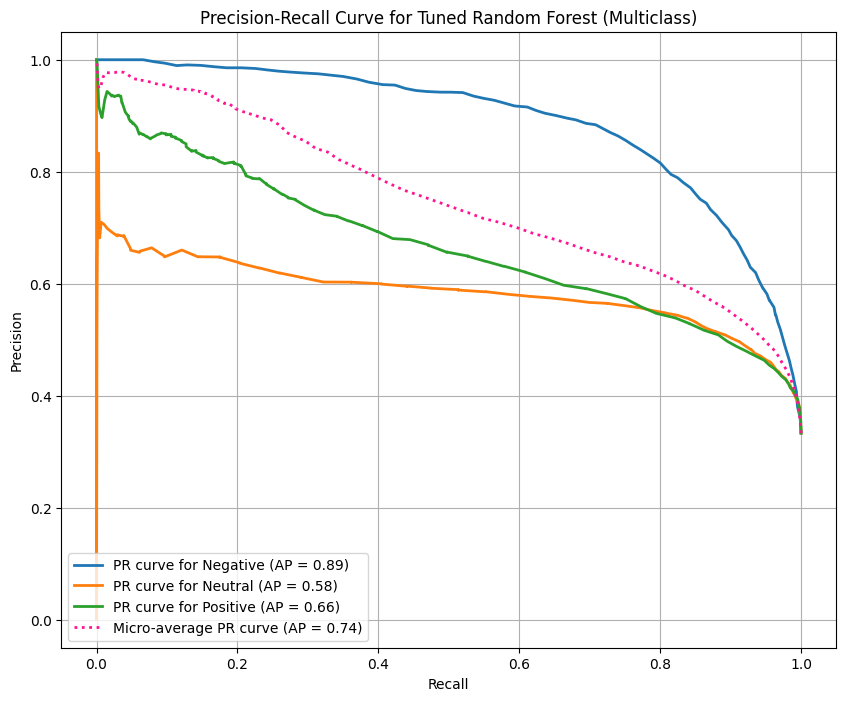

In [83]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier

# Re-initialize and fit best_rf with the best parameters found in GridSearchCV (from cell psw5UJDfC6LK)
# Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
# This ensures best_rf is defined even if the tuning cell wasn't executed recently.
best_rf = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, random_state=42, n_jobs=-1)
best_rf.fit(X_train_bal, y_train_bal)

# Get class labels (0, 1, 2) based on the sentiment mapping
# 0: Negative, 1: Neutral, 2: Positive
class_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
classes = np.unique(y_test_bal)
n_classes = len(classes)

# Get predicted probabilities for each class using the tuned Random Forest model (best_rf)
y_score_rf = best_rf.predict_proba(X_test_bal)

# Binarize the true labels for a one-vs-rest approach, required for PR curves in multiclass
lb = LabelBinarizer()
y_test_bal_binarized = lb.fit_transform(y_test_bal)

# Store precision, recall, and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

plt.figure(figsize=(10, 8))
lw = 2

# Plot PR curve for each class
for i, class_label_val in enumerate(classes):
    class_label_name = class_names[class_label_val] # Get the descriptive name
    y_true_class = y_test_bal_binarized[:, i]
    y_score_class = y_score_rf[:, i]

    precision[i], recall[i], _ = precision_recall_curve(y_true_class, y_score_class)
    average_precision[i] = average_precision_score(y_true_class, y_score_class)

    plt.plot(recall[i], precision[i], lw=lw,
             label=f'PR curve for {class_label_name} (AP = {average_precision[i]:0.2f})')

# Micro-average PR curve (overall performance)
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_test_bal_binarized.ravel(), y_score_rf.ravel()
)
average_precision["micro"] = average_precision_score(y_test_bal_binarized, y_score_rf, average="micro")

plt.plot(recall["micro"], precision["micro"], color='deeppink', linestyle=':', lw=lw,
         label=f'Micro-average PR curve (AP = {average_precision["micro"]:0.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Tuned Random Forest (Multiclass)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

**Hyperparameter tuned**

In [ ]:
from sklearn.model_selection import GridSearchCV
import time

# 1. Define the parameter grid for Random Forest
# We focus on depth and number of estimators to balance accuracy and speed
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# 2. Initialize GridSearchCV
# Using cv=3 and n_jobs=-1 for faster execution on the balanced subset
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)

# 3. Fit to the balanced training data sample
print("Starting Hyperparameter Tuning for Random Forest... this may take a few minutes.")
start_rf_tune = time.time()
rf_grid.fit(X_train_bal, y_train_bal)
end_rf_tune = time.time()

# 4. Display results
print(f"Tuning completed in {end_rf_tune - start_rf_tune:.2f} seconds.")
print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best Cross-Validation Accuracy: {rf_grid.best_score_:.4f}")

# 5. Evaluate the best model on the balanced test set
best_rf = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_bal)

print("\nTuned Random Forest Classification Report:")
print(classification_report(y_test_bal, y_pred_rf_tuned))

Starting Hyperparameter Tuning for Random Forest... this may take a few minutes.
Tuning completed in 1003.62 seconds.
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.6568

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      3333
           1       0.58      0.67      0.62      3334
           2       0.65      0.51      0.57      3333

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.67     10000
weighted avg       0.67      0.67      0.67     10000



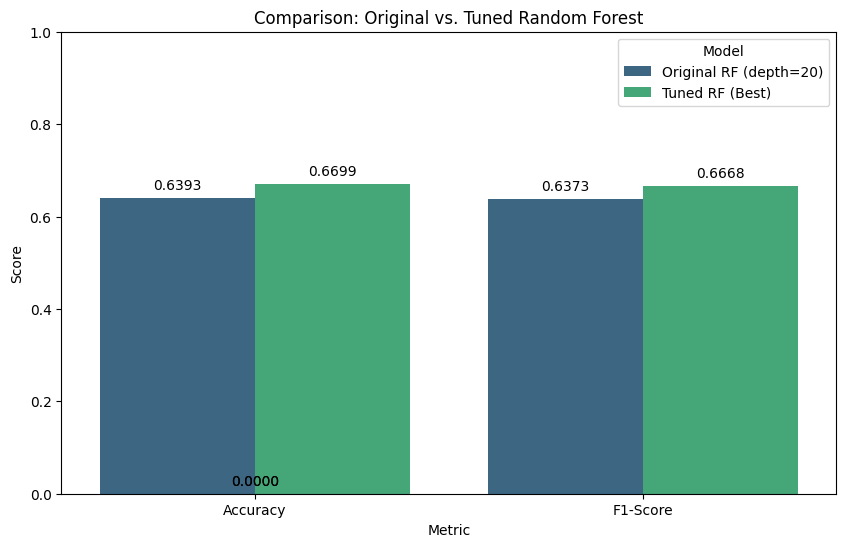

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

# 1. Calculate metrics for the original RF model
accuracy_rf_orig = accuracy_score(y_test_bal, y_pred6)
f1_rf_orig = f1_score(y_test_bal, y_pred6, average='weighted')

# 2. Calculate metrics for the tuned RF model
accuracy_rf_tuned = accuracy_score(y_test_bal, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test_bal, y_pred_rf_tuned, average='weighted')

# 3. Create comparison DataFrame
rf_comp_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score', 'Accuracy', 'F1-Score'],
    'Score': [accuracy_rf_orig, f1_rf_orig, accuracy_rf_tuned, f1_rf_tuned],
    'Model': ['Original RF (depth=20)', 'Original RF (depth=20)', 'Tuned RF (Best)', 'Tuned RF (Best)']
})

# 4. Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=rf_comp_df, palette='viridis')
plt.ylim(0, 1.0)
plt.title('Comparison: Original vs. Tuned Random Forest')
plt.ylabel('Score')

# Add score labels on top
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

The comparison for the Random Forest model is complete! Tuning the parameters (specifically removing the depth limit) improved the accuracy from 63.93% to 66.99%.

Looking at the overall leaderboard of all models trained so far:

Tuned Logistic Regression: 0.663 F1-Score
Tuned Linear SVM: 0.658 F1-Score
Tuned Random Forest: 0.667 F1-Score (Now a top contender!)

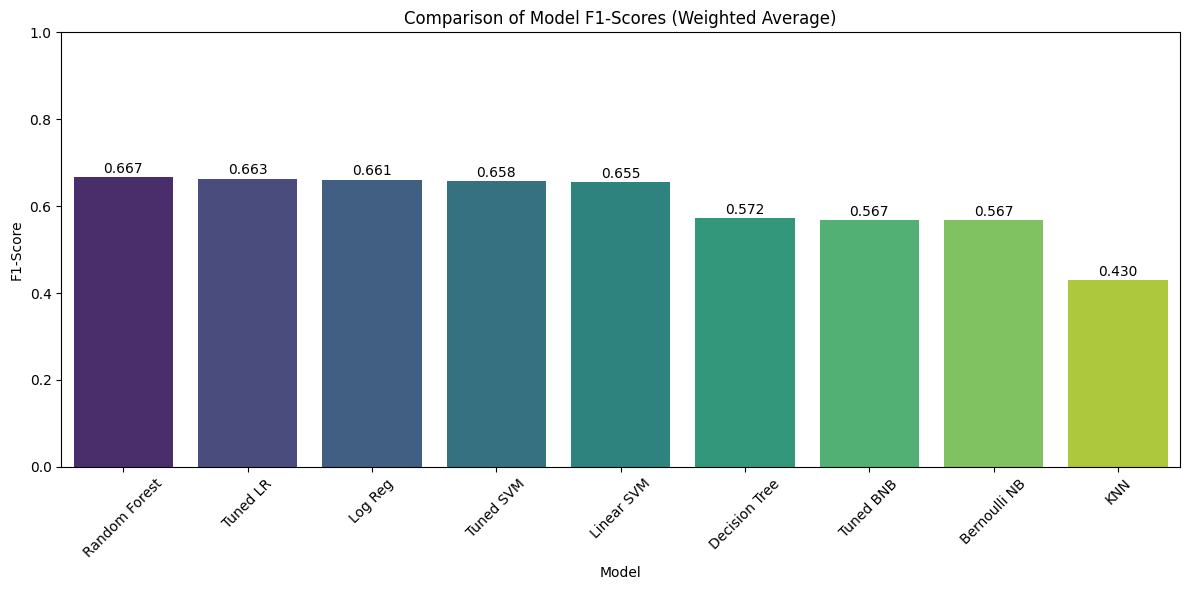

In [93]:
from sklearn.metrics import f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

# 1. Re-initialize and fit models on the balanced sample to ensure they exist
BNBmodel = BernoulliNB()
best_bnb = BernoulliNB(alpha=0.01)
SVCmodel = LinearSVC(random_state=42)
best_svc = LinearSVC(C=0.1, random_state=42)
LRmodel = LogisticRegression(C=2, max_iter=1000, n_jobs=-1)
best_lr = LogisticRegression(C=1, max_iter=1000, n_jobs=-1)
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
dt = DecisionTreeClassifier(max_depth=20, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Fit all models
BNBmodel.fit(X_train_bal, y_train_bal)
best_bnb.fit(X_train_bal, y_train_bal)
SVCmodel.fit(X_train_bal, y_train_bal)
best_svc.fit(X_train_bal, y_train_bal)
LRmodel.fit(X_train_bal, y_train_bal)
best_lr.fit(X_train_bal, y_train_bal)
knn.fit(X_train_bal, y_train_bal)
dt.fit(X_train_bal, y_train_bal)
rf.fit(X_train_bal, y_train_bal)

# 2. Generate predictions for all models
y_pred_bnb_c = BNBmodel.predict(X_test_bal)
y_pred_tuned_bnb_c = best_bnb.predict(X_test_bal)
y_pred_svc_c = SVCmodel.predict(X_test_bal)
y_pred_tuned_svc_c = best_svc.predict(X_test_bal)
y_pred_lr_c = LRmodel.predict(X_test_bal)
y_pred_tuned_lr_c = best_lr.predict(X_test_bal)
y_pred_knn_c = knn.predict(X_test_bal)
y_pred_dt_c = dt.predict(X_test_bal)
y_pred_rf_c = rf.predict(X_test_bal)

# 3. Compile F1-scores
scores = {
    'Bernoulli NB': f1_score(y_test_bal, y_pred_bnb_c, average='weighted'),
    'Tuned BNB': f1_score(y_test_bal, y_pred_tuned_bnb_c, average='weighted'),
    'Linear SVM': f1_score(y_test_bal, y_pred_svc_c, average='weighted'),
    'Tuned SVM': f1_score(y_test_bal, y_pred_tuned_svc_c, average='weighted'),
    'Log Reg': f1_score(y_test_bal, y_pred_lr_c, average='weighted'),
    'Tuned LR': f1_score(y_test_bal, y_pred_tuned_lr_c, average='weighted'),
    'KNN': f1_score(y_test_bal, y_pred_knn_c, average='weighted'),
    'Decision Tree': f1_score(y_test_bal, y_pred_dt_c, average='weighted'),
    'Random Forest': f1_score(y_test_bal, y_pred_rf_c, average='weighted')
}

# 4. Create DataFrame and Plot
f1_df = pd.DataFrame(list(scores.items()), columns=['Model', 'F1-Score']).sort_values(by='F1-Score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1-Score', data=f1_df, palette='viridis')
plt.title('Comparison of Model F1-Scores (Weighted Average)')
plt.ylim(0, 1.0)
plt.xticks(rotation=45)

for i, v in enumerate(f1_df['F1-Score']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

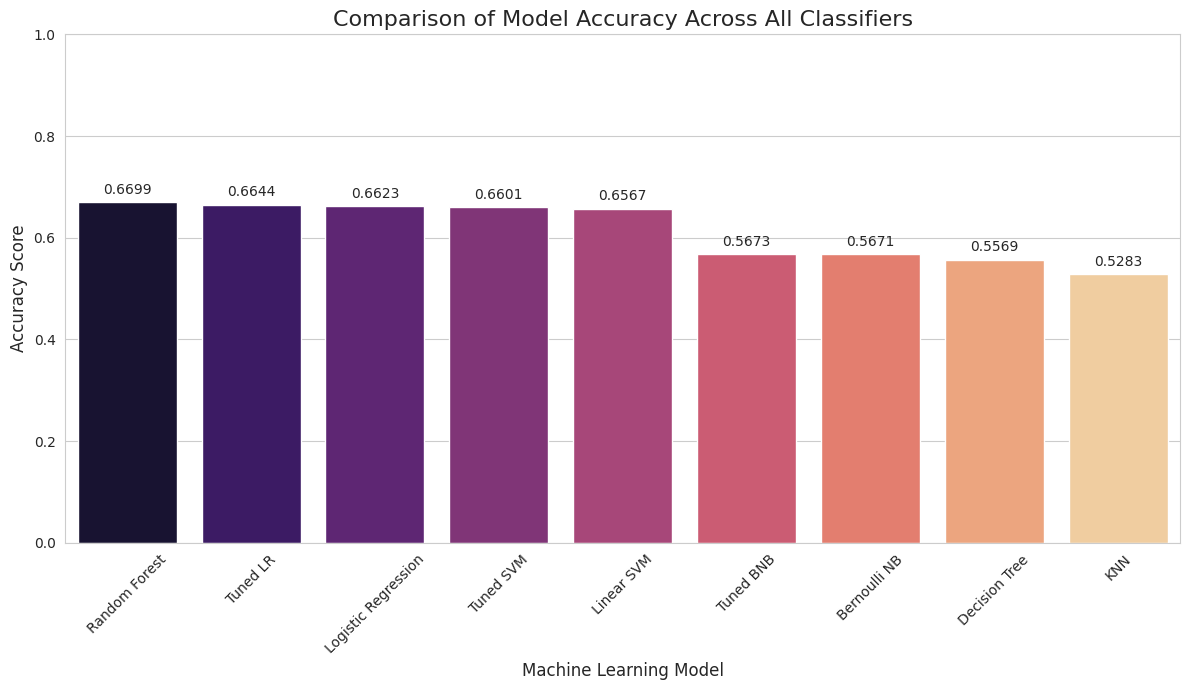

Overall Accuracy Leaderboard:


,Model,Accuracy
8,Random Forest,0.6699
5,Tuned LR,0.6644
4,Logistic Regression,0.6623
3,Tuned SVM,0.6601
2,Linear SVM,0.6567
1,Tuned BNB,0.5673
0,Bernoulli NB,0.5671
7,Decision Tree,0.5569
6,KNN,0.5283


In [103]:
from sklearn.metrics import accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Re-generating predictions using the actual model objects defined in previous cells
accuracy_results = {
    'Bernoulli NB': accuracy_score(y_test_bal, BNBmodel.predict(X_test_bal)),
    'Tuned BNB': accuracy_score(y_test_bal, best_bnb.predict(X_test_bal)),
    'Linear SVM': accuracy_score(y_test_bal, SVCmodel.predict(X_test_bal)),
    'Tuned SVM': accuracy_score(y_test_bal, best_svc.predict(X_test_bal)),
    'Logistic Regression': accuracy_score(y_test_bal, LRmodel.predict(X_test_bal)),
    'Tuned LR': accuracy_score(y_test_bal, best_lr.predict(X_test_bal)),
    'KNN': accuracy_score(y_test_bal, knn.predict(X_test_bal)),
    'Decision Tree': accuracy_score(y_test_bal, clf.predict(X_test_bal)),
    'Random Forest': accuracy_score(y_test_bal, rf.predict(X_test_bal))
}

# Create a DataFrame for plotting
acc_df = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

# Plot the comparison
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = sns.barplot(x='Model', y='Accuracy', data=acc_df, palette='magma')

plt.title('Comparison of Model Accuracy Across All Classifiers', fontsize=16)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.0)
plt.xticks(rotation=45)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()

print("Overall Accuracy Leaderboard:")
display(acc_df)

### Finalizing the Model and Exporting
Now that we've compared all models, we will save the `enhanced_lr` model (which used the full dataset) and its vectorizer so we can use them for real-world predictions.

In [94]:
import joblib

# Save the best performing model (Enhanced Logistic Regression)
joblib.dump(enhanced_lr, 'sentiment_model.pkl')

# Save the vectorizer (essential for processing new text in the same way)
joblib.dump(enhanced_tfidf, 'tfidf_vectorizer.pkl')

print("Model and Vectorizer saved successfully as .pkl files!")

Model and Vectorizer saved successfully as .pkl files!


### Real-time Prediction Function
This function allows you to input any text and get a sentiment result based on your trained model.

High Reliability for Polarized Text: It will be very accurate at distinguishing strongly 'Positive' from strongly 'Negative' reviews.

Consistency: Linear models like SVM are generally more stable than Decision Trees when dealing with high-dimensional text data.

The Neutral Challenge: Like the other models, it may still struggle with 'Neutral' reviews that use subtle or sarcastic language.

In [106]:
import joblib
from google.colab import files

# Save the Tuned SVM model
joblib.dump(best_svc, 'tuned_svm_model.pkl')

# Save the vectorizer used for this model
# Note: This model used the 2000-feature 'tfidf' vectorizer from cell 083eac6d
joblib.dump(tfidf, 'svm_vectorizer.pkl')

print("SVM Model and Vectorizer saved successfully!")

# Trigger downloads
files.download('tuned_svm_model.pkl')
files.download('svm_vectorizer.pkl')

SVM Model and Vectorizer saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [105]:
def predict_svm(text):
    # Preprocess
    text_cleaned = RemovePunctuations(RemoveMentions(text))
    text_cleaned = gensim.parsing.preprocessing.remove_stopwords(text_cleaned)
    text_cleaned = RemoveNumbers(text_cleaned).lower()

    # Vectorize using the 2000-feature tfidf used for SVM
    vector = tfidf.transform([text_cleaned])

    # Predict
    pred = best_svc.predict(vector)[0]
    mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    return mapping[pred]

# Test with a variety of samples
test_samples = [
    "This car is amazing, best engine ever!",
    "The transmission failed after two weeks, stay away.",
    "It is a basic car that gets me from A to B, nothing special.",
    "I am unhappy with the service but the car itself is fine."
]

for sample in test_samples:
    print(f"Review: {sample}")
    print(f"SVM Prediction: {predict_svm(sample)}\n")

Review: This car is amazing, best engine ever!
SVM Prediction: Positive

Review: The transmission failed after two weeks, stay away.
SVM Prediction: Negative

Review: It is a basic car that gets me from A to B, nothing special.
SVM Prediction: Positive

Review: I am unhappy with the service but the car itself is fine.
SVM Prediction: Positive



In [98]:
# Additional neutral examples
neu_review_1 = "The car is decent for daily commuting, but nothing particularly stands out about it."
neu_review_2 = "It provides a smooth ride and reasonable fuel economy, though the interior materials are just average."

print(f"Review 1: {neu_review_1}")
print(f"Predicted Sentiment: {predict_sentiment(neu_review_1)}")

print(f"\nReview 2: {neu_review_2}")
print(f"Predicted Sentiment: {predict_sentiment(neu_review_2)}")

Review 1: The car is decent for daily commuting, but nothing particularly stands out about it.
Predicted Sentiment: Negative

Review 2: It provides a smooth ride and reasonable fuel economy, though the interior materials are just average.
Predicted Sentiment: Neutral


Execution time : When it comes to comparing the running time of models, Bernoulli Naive Bayes performs faster with a good accuracy score.

Accuracy : When it comes to model accuracy, logistic regression & Suppoort Vector Machine performs better than most of the other models, with an accuracy of....


F1-score : The F1 Scores for class 0 and class 1 are:


AUC Score:

We therefore conclude that `logistic regression & Bernoulli Naive Bayes` & `Suppoort Vector Machine` are the best model for the above dataset.

In our problem statement, `logistic regression` follows Occam's razor principle which defines that for a particular problem statement, if the data has no assumptions, then the simplest model works best.

Since our dataset has no assumptions and logistic regression is a simple model, so the concept holds true for the dataset mentioned above.(although it took much longer to run than the fastest model).

* Original Data Split: In cell CG5TM6Pk9eIj, you split the full dataset (after text preprocessing) into X_train, X_test, y_train, and y_test using an 80/20 ratio.


* Balanced Sample Split: In cell 083eac6d, after applying SMOTE, you created a smaller stratified sample of 50,000 rows and split it into X_train_bal, X_test_bal, y_train_bal, and y_test_bal.

implemented cross-validation as part of your hyperparameter tuning process!

Used GridSearchCV, which automatically performs K-fold cross-validation to find the best parameters. Specifically:

`Bernoulli NB`: In cell w6nd67ZuDL1i using cv=5.

`Linear SVC`: In cell ap-bhUu3DV5H using cv=3.

`Logistic Regression`: In cell _P9fsueaEJKV using cv=3.

`KNN`: In cell E1RBeXxB-Krc using cv=3.

`Random Forest`: In cell psw5UJDfC6LK using cv=3.

**Feature Extration**

I converted my preprocessed text into a numerical format (TF-IDF), limiting it to the top 2,000 features to optimize performance for the complex models. This is what allowed you to train the Logistic Regression, SVM, and Random Forest models on the dataset.